# prep

In [1]:
account_path = '/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/'

In [2]:
# mount the drive
from google.colab import drive
drive.mount('/content/drive/')
from google.colab import auth
auth.authenticate_user()

# load packages - basics
!pip install pynrrd
import os
import csv
import numpy as np
import pandas as pd
import math
import time
import json
import nrrd

Mounted at /content/drive/


In [3]:
# load packages - stats
!pip install scikit-posthocs
import scipy
from scipy import io
from scipy.fftpack import rfft, irfft, fftfreq
import scipy.stats as stats
from scipy.stats import zscore

import statsmodels.api as sm
import statsmodels.formula.api as smf
import scikit_posthocs as scikit
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels

import random
from random import randrange, shuffle
import itertools
from itertools import combinations
import sklearn
from sklearn.decomposition import PCA, FastICA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score

In [4]:
# load packages - plotting and template settings
import matplotlib as mpl
from matplotlib import pyplot as plt
%matplotlib inline

from matplotlib.patches import Rectangle
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import animation
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import pickle

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## fcn.

In [5]:
import gspread
from google.auth import default

def read_metadata(gsheet_url,tab_name):
  """This script reads information in a tab in the Google sheet, where metadata for each experiment is stored.
  """
  # import gspread
  # from google.auth import default

  # reading in google sheet with experimental details
  creds, _ = default()
  gc = gspread.authorize(creds)

  # insert URl of gsheet, specify worksheets as different variables
  wb = gc.open_by_url(gsheet_url)
  exps = wb.worksheet(tab_name)

  #
  all_data = pd.DataFrame(exps.get_all_records())
  metadata = all_data.set_index('experiment')
  display(all_data)

  return metadata

In [6]:
from scipy.interpolate import interp1d
def resample_to_max_length(list_of_arrays):
    max_len = max(len(arr) for arr in list_of_arrays)
    resampled = []
    for arr in list_of_arrays:
        x_old = np.linspace(0, 1, len(arr))
        x_new = np.linspace(0, 1, max_len)
        f = interp1d(x_old, arr, kind='linear', fill_value='extrapolate')
        resampled.append(f(x_new))
    return np.array(resampled), max_len

## config

In [7]:
# figures output parameters
mpl.rcParams['lines.linewidth'] = 1        # default line width
mpl.rcParams['patch.linewidth'] = 0
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

# Set global Matplotlib parameters for PDF output
mpl.rcParams['pdf.fonttype'] = 42          # Use TrueType fonts (editable text)

mpl.rcParams['figure.figsize'] = (4,3)     # Default figure size in inches
mpl.rcParams['axes.titlesize'] = 16        # Title font size
mpl.rcParams['axes.labelsize'] = 14        # Axis label font size
mpl.rcParams['xtick.labelsize'] = 10       # X-axis tick label size
mpl.rcParams['ytick.labelsize'] = 10       # Y-axis tick label size
mpl.rcParams['legend.fontsize'] = 8        # Legend font size
mpl.rcParams['savefig.dpi'] = 300          # DPI for high-quality export (relevant for raster elements)
mpl.rcParams['savefig.transparent'] = True # Ensures background is transparent
sns.set(style="white",font_scale=1)     # global scaling of all texts
mpl.rcParams['xtick.bottom'] = True        # make sure ticks visible
mpl.rcParams['ytick.left'] = True

mpl.rcParams['xtick.major.width'] = 0.5    # X-axis major tick width
mpl.rcParams['ytick.major.width'] = 0.5    # Y-axis major tick width
mpl.rcParams['axes.linewidth'] = 0.5       # Axis line width

from cycler import cycler
# remove red from the default colors
mpl.rcParams['axes.prop_cycle'] = cycler('color', ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])

In [17]:
figure_path = account_path + 'Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/'
csv_path = account_path + 'Yu_escape_paper/Manuscript/Figures/figures_v8/csvs/'

# Data (dots do stuff)

In [10]:
# directories for the data and analysis
gsheet = 'https://docs.google.com/spreadsheets/d/1tpUkPiWTz_j2fthNLOIQvooPCbYnScKaoHLthi5yq18/edit?gid=106031496#gid=106031496'
tab_name = 'four_stim'

path = account_path + 'Yu_escape_paper/Imaging/Dots_do_stuff/'
data_path = path + 'Data/'
save_path = path + 'Analysis/'

metadata = read_metadata(gsheet,tab_name)
experiments = metadata.index
fcn_files = metadata.fcn_file
planeNum = metadata.planeNum
trialNum = metadata.trialNum

,experiment,fcn_file,planeNum,ROI_csv,trialNum,atlas_1,atlas_2,
0,jy-241126-f2,t2-stimR,2,2,10 9 10 10,58-77,65-84,
1,jy-241126-f4,t1-stimL,2,2,6 6 5 6,69-62,81-76,
2,jy-241126-f4,t2-stimR,2,2,5 4 5 4,76-69,83-77,
3,jy-241126-f4,t3-stimL,2,2,4 4 4 4,68-60,80-73,
4,jy-241203-f2,t1-stimL,2,2,7 7 7 8,76-58,91-74,
5,jy-241203-f2,t2-stimR,2,2,8 9 8 9,78-60,98-80,
6,jy-241203-f2,t3-stimR,1,1,10 10 10 9,88-70,,
7,jy-241203-f3,t1-stimL,2,2,9 9 10 9,75-68,88-83,
8,jy-241203-f3,t2-stimR,2,2,10 10 10 10,77-71,86-80,good brain
9,jy-241203-f3,t3-stimL,1,1,8 8 9 8,72-66,,


## stim type color scheme

In [11]:
# establish stim type num, names, and colors
resample_Hz = 10
stim_names = ['Linear','Loom','BM','BM-escape']

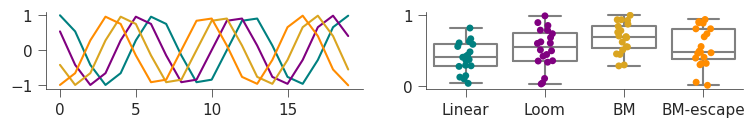

In [12]:
group_num = len(stim_names); group_names = stim_names
tmp = {n: np.random.random(20) for n in stim_names};

stim_colorz = ['teal','purple','goldenrod','darkorange']
# validate colors settings work with both major plotting packages
plt.figure(figsize=[9,1]); plt.subplot(121);
for igs, gs in enumerate(group_names): plt.plot(np.cos(np.arange(igs,igs+20)),c=stim_colorz[igs]);
tmp = {n: np.random.random(20) for n in group_names};
plt.subplot(122); sns.boxplot(data=tmp,fill=False,color='gray'); sns.stripplot(data=tmp,palette=stim_colorz); sns.despine();
plt.show()

# S6a - workflow of making VR trajectories with behavior tracking


In [ ]:
def VR_2pscreens():
  """This script visualize the screens of VR rig on top down 2D plane
  """
  from re import X
  import math
  import numpy as np
  # VR screen in the cube mapping
  tilt_dg1 = math.radians(-83.5)
  tilt_dg2 = math.radians(83.5)

  screen1x = [-3.85 - 8*math.cos(tilt_dg1), -3.85 + 8*math.cos(tilt_dg1)]
  screen1y = [0 + 8*math.sin(tilt_dg1), 0 - 8*math.sin(tilt_dg1)]
  screen2x = [3.85 - 8*math.cos(tilt_dg2), 3.85 + 8*math.cos(tilt_dg2)]
  screen2y = [0 + 8*math.sin(tilt_dg2), 0 - 8*math.sin(tilt_dg2)]
  # equation ~ y = -8.776887356869949x -33.79 or y = 8.776887356869949x +33.79

  # visual field boundary
  x1 = np.linspace(0, screen2x[0]*100,200)
  X2 = np.linspace(0, screen2x[1]*100,200)
  x3 = np.linspace(0, screen1x[0]*100,200)
  x4 = np.linspace(0, screen1x[1]*100,200)
  y1 = np.linspace(0, screen2y[0]*100,200)
  y2 = np.linspace(0, screen2y[1]*100,200)
  y3 = np.linspace(0, screen1y[0]*100,200)
  y4 = np.linspace(0, screen1y[1]*100,200)


  xx = np.concatenate((x1,X2,x3,x4))
  yy = np.concatenate((y1,y2,y3,y4))

  # eye point and screens
  plt.scatter(0,0,c='red',s=3)
  plt.plot(screen1x,screen1y,c='black')
  plt.plot(screen2x,screen2y,c='black')
  # # visual field
  # plt.plot(xx,yy,c='gray',alpha=.25)

In [ ]:
path = '/content/drive/MyDrive/Colab Notebooks/Johsien/VR_stimuli/Data/2p_csv/'

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v6/subpanels/S7a-social_stim_topdown_pov


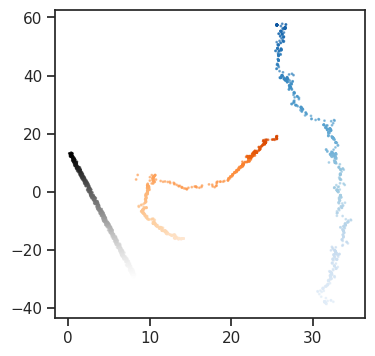

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v6/subpanels/S7a-social_stim_hybrid_topdown_VR


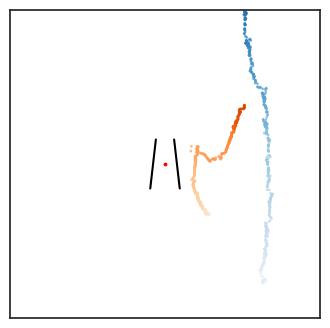

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v6/subpanels/S7a-social_stim_hybrid_side_pov


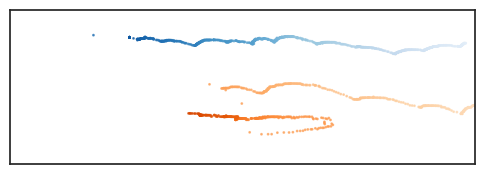

In [ ]:
subpanel = 'S7a'

f1_td = pd.read_csv(path + 'swim_f1/120Hz_R.csv'); f1_sd = pd.read_csv(path + 'swim_f1/120Hz_side.csv')
f2_td = pd.read_csv(path + 'escape_f1/0.2x_120Hz_R.csv'); f2_sd = pd.read_csv(path + 'escape_f1/120Hz_side.csv')

cmap1 = plt.colormaps['Blues']; cmap2 = plt.colormaps['Oranges']
colors1 = (cmap1(np.linspace(0.1,0.85,len(f1_td))))
colors2 = (cmap2(np.linspace(0.1,0.75,len(f2_td))))
combined_cmap1 = mcolors.ListedColormap(colors1);
combined_cmap2 = mcolors.ListedColormap(colors2);

# original from top down
plt.figure(figsize=(4,4))
plt.scatter(f1_td['N_X']+5,f1_td['N_Y']*(-1),c=np.arange(len(f1_td)), cmap=combined_cmap1, s=1,alpha=0.6) #
plt.scatter(f2_td['N_X']+3,f2_td['N_Y']*(-1),c=np.arange(len(f2_td)), cmap=combined_cmap2, s=1,alpha=0.6)
plt.scatter(np.linspace(8,0,len(f1_td))+np.random.rand(len(f1_td))*0.5,\
            np.linspace(-30,13,len(f1_td))+np.random.rand(len(f1_td))*0.5,c=np.arange(len(f1_td)), cmap="Greys", s=1,alpha=0.6)

print(figure_path+subpanel+'-social_stim_topdown_pov')
plt.savefig(figure_path+subpanel+'-social_stim_topdown_pov.pdf',bbox_inches='tight')
plt.show()

# hybrid from top down
plt.figure(figsize=(4,4))
plt.scatter(f1_td['N_X']+5,f1_td['N_Y']*(-1),c=np.arange(len(f1_td)), cmap=combined_cmap1, s=1,alpha=0.6) #'Blues'
plt.scatter(f2_td['N_X']+3,f2_td['N_Y']*(-1),c=np.arange(len(f2_td)), cmap=combined_cmap2, s=1,alpha=0.6) #'Oranges'
plt.xlim(-50,50); plt.ylim(-50,50); plt.xticks([]); plt.yticks([])
VR_2pscreens()

print(figure_path+subpanel+'-social_stim_hybrid_topdown_VR')
plt.savefig(figure_path+subpanel+'-social_stim_hybrid_topdown_VR.pdf',bbox_inches='tight')
plt.show()

# hybrid from the side
plt.figure(figsize=(6,2))
plt.scatter(f1_sd['N_X'],f1_sd['N_Y']+5,c=np.arange(len(f1_td)), cmap=combined_cmap1, s=1,alpha=0.7)
plt.scatter(f2_sd['N_X'],f2_sd['N_Y'],c=np.arange(len(f2_td)), cmap=combined_cmap2, s=1,alpha=0.7)
plt.xlim(0,1000); plt.ylim(0,15); plt.xticks([]); plt.yticks([])

print(figure_path+subpanel+'-social_stim_hybrid_side_pov')
plt.savefig(figure_path+subpanel+'-social_stim_hybrid_side_pov.pdf',bbox_inches='tight')
plt.show()

# S6b - 2-axis design of stimuli

In [ ]:
tmp_path = '/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Imaging/Dots_do_stuff/Data/'

## area (from Bonsai model)

In [ ]:
# NUMBER of sphere(s): # 1x (linear), 3x (BM), 3x (BM-escape)
# SIZE: scaling factors: 2x2x2 for sphere and loom, 1.5x1.5x1.5 for swim and escape
# size of smoothed sphere (.obj dimension - 2x2x2 unitless)
print('per sphere area (cm^2):' ,'linear', 2*2, 'BM', 1.5*1.5)
print('total area (cm^2):', 'linear', 2*2*1, 'BM', 1.5*1.5*3)


per sphere area (cm^2): linear 4 BM 2.25
total area (cm^2): linear 4 BM 6.75


## speed (from csv coordinates)

In [ ]:
# SPEED

# position (take 120Hz_R)
# (1) sphere
x0, y0 = 20, -15; x1, y1 = 20, 10
displacement = np.sqrt((x1-x0)**2+(y1-y0)**2)
speed = displacement/4.5
print(f'Linear motion, speed = {speed:.2f} cm/s')

# (2) loom
x0, y0 = 20, -15; x1, y1 = 0, -2
displacement = np.sqrt((x1-x0)**2+(y1-y0)**2)
speed = displacement/4.5
radius = 2*2 # cm
ssr = radius/speed*1000
print(f'Looming motion, speed = {speed:.2f} cm/s, size speed ratio = {ssr:.2f} ms')

# (3) swim
print('Swimming dots')
all_swim = []
for f in range(3):
  if f ==2:
    data_x = pd.read_csv(tmp_path + f'swim-f1_120Hz_R.csv', header=0)
    data_y = pd.read_csv(tmp_path + f'swim-f2_120Hz_R.csv', header=0)
    frame_num = data_x.shape[0]
    x0, y0 = data_x['N_X'][0], data_y['N_Y'][0]
    x1, y1 = data_x['N_X'][frame_num-1], data_y['N_Y'][frame_num-1]
  else:
    data = pd.read_csv(tmp_path + f'swim-f{f+1}_120Hz_R.csv', header=0)
    frame_num = data.shape[0]/2
    x0, y0 = data['N_X'][0], data['N_Y'][0]
    x1, y1 = data['N_X'][frame_num-1], data['N_Y'][frame_num-1]

  displacement = np.sqrt((x1-x0)**2+(y1-y0)**2)
  speed = displacement/6
  print(f'  fish{f+1}, speed = {speed:.2f} cm/s')
  all_swim.append(speed)
print(f'mean speed during swim = {np.mean(all_swim):.2f} cm/s')

# (4) escape
print('Escaping dots (before escape)')
all_escape = []
for f in range(3):
  if f ==2:
    data_x = pd.read_csv(tmp_path + f'esp-f1_120Hz_R.csv', header=0)
    data_y = pd.read_csv(tmp_path + f'esp-f2_120Hz_R.csv', header=0)
    frame_num = data_x.shape[0]/2
    x0, y0 = data_x['N_X'][0], data_y['N_Y'][0]
    x1, y1 = data_x['N_X'][frame_num-1], data_y['N_Y'][frame_num-1]
  else:
    data = pd.read_csv(tmp_path + f'esp-f{f+1}_120Hz_R.csv', header=0)
    frame_num = data.shape[0]/2
    x0, y0 = data['N_X'][0], data['N_Y'][0]
    x1, y1 = data['N_X'][frame_num-1], data['N_Y'][frame_num-1]
  displacement = np.sqrt((x1-x0)**2+(y1-y0)**2)
  speed = displacement/6
  print(f'  fish{f+1}, speed = {speed:.2f} cm/s')
  all_escape.append(speed)
print(f'mean speed befor escape = {np.mean(all_escape):.2f} cm/s')

Linear motion, speed = 5.56 cm/s
Looming motion, speed = 5.30 cm/s, size speed ratio = 754.60 ms
Swimming dots
  fish1, speed = 8.69 cm/s
  fish2, speed = 2.57 cm/s
  fish3, speed = 4.92 cm/s
mean speed during swim = 5.39 cm/s
Escaping dots (before escape)
  fish1, speed = 3.68 cm/s
  fish2, speed = 2.70 cm/s
  fish3, speed = 2.76 cm/s
mean speed befor escape = 3.05 cm/s


# S6c - cell recorded per plane

In [13]:
cell_per_session = {'per session':[], 'fish_ids':[]};
cell_per_plane = {'per plane':[]}

for exp, ffile, plane_num, trial_num in zip(experiments, fcn_files, planeNum, trialNum):
  load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'
  # load processed data
  data = np.load(load_path+'neuron_details.npz', allow_pickle=True)
  traces_Z = data['traces_Z']

  # print("fish #", exp, ': ', ffile)
  cell_per_session['per session'].append(traces_Z.shape[0])
  [cell_per_plane['per plane'].append(traces_Z.shape[0]/plane_num) for i in range(plane_num)]
  cell_per_session['fish_ids'].append(exp)

for key, val in cell_per_session.items():
  cell_per_session[key] = np.array(val)
#
cell_per_fish = {'fish_ids':[], 'per fish':[]}
for fish in np.unique(cell_per_session['fish_ids']):
  cnt = np.sum(cell_per_session['per session']*[cell_per_session['fish_ids']==fish])
  cell_per_fish['per fish'].append(cnt)
  cell_per_fish['fish_ids'].append(fish)

cell_per_fish.pop('fish_ids')
print('done')

done



Each point is mean cell count from a plane
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/S6c


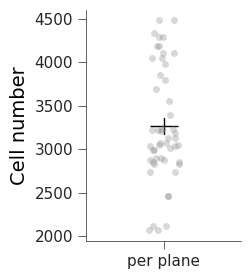

Ns, means, and  sems:
(N=50) 3267.080 ± 92.939


,per plane
0,4107.0
1,4107.0
2,2994.5
3,2994.5
4,2826.5
5,2826.5
6,2900.5
7,2900.5
8,3043.5
9,3043.5


In [18]:
subpanel = 'S6c'

summary_data = cell_per_plane
# PLOT
print('\nEach point is mean cell count from a plane')
plt.figure(figsize=[2,3])
sns.stripplot(data=summary_data,color='gray',alpha=0.3,size=5)
sns.pointplot(data=summary_data,color='black',linestyle="none",marker="_",estimator='mean',errorbar='se',markersize=20,markeredgewidth=1,errwidth=1);
plt.ylabel('Cell number',fontsize=14, color='black');
sns.despine();
print(figure_path+subpanel)
# plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()
# STATS
print("Ns, means, and  sems:")
print(f"(N={len(summary_data['per plane'])}) {np.mean(summary_data['per plane']):.3f} ± {scipy.stats.sem(summary_data['per plane']):.3f}")

# save source data into csv
series_dict = {'per plane': cell_per_plane['per plane']}
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv')

# S6d - cell recorded per brain region

In [ ]:
# forebrain: forebrain, habenula
# midbrain: tectum_left, tectum_right, midbrain
# hindbrain: cerebellum, hindbrain

# count from each session
regions = ['forebrain','midbrain','hindbrain']
cell_by_region = {n: 0 for n in regions};
subregions = {'forebrain': ['forebrain','habenula'],'thalamus':['thalamus'],'tectum':['tectum_left','tectum_right'], 'hindbrain':['hindbrain','cerebellum']}
cell_by_subregion = {subreg_name: 0 for subreg_name,subreg in subregions.items()}

for exp, ffile, plane_num in zip(experiments, fcn_files, planeNum):
  load_path = data_path + exp + '/' + ffile + '/';
  output_path = save_path + exp + '/' + ffile + '/'
  # print("fish #", exp, ': ', ffile)

  # load cell xy positions
  data = np.load(load_path+'neuron_details.npz', allow_pickle=True)
  xs, ys, zs = data['xs'], data['ys'], data['zs']

  # load anatomy
  with open(load_path+'neuron_anatomy.pkl', 'rb') as f:
    cell_locations = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]

  for icell in range(len(cell_locations))[::]:
    # print(icell, cell_locations[icell])
    if cell_locations[icell] == []: continue
    for reg in regions:
      if reg in cell_locations[icell]:
        # print(f"part of {reg}")
        cell_by_region[reg]+=1
    for subreg_name, subregs in subregions.items():
      for subreg in subregs:
        if subreg in cell_locations[icell]:
          # print(f"also part of {subreg_name}")
          cell_by_subregion[subreg_name]+=1

print('done')

done


/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S6d


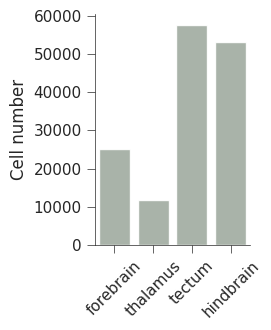

,forebrain,thalamus,tectum,hindbrain
0,25101,11823,57649,53040


In [ ]:
subpanel = 'S6d'

summary_data = cell_by_subregion
# PLOT
plt.figure(figsize=[2,3])
sns.barplot(data=summary_data,color='darkseagreen',alpha=0.9,saturation=0.25)
plt.ylabel('Cell number'); plt.xticks(rotation=45); sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
for key, val in cell_by_subregion.items():
  series_dict[key] = pd.Series(val)
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv')

# S6e - example lateralization of visually responsive cells

fish # jy-241203-f3 :  t1-stimL
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S6e-t1-stimL


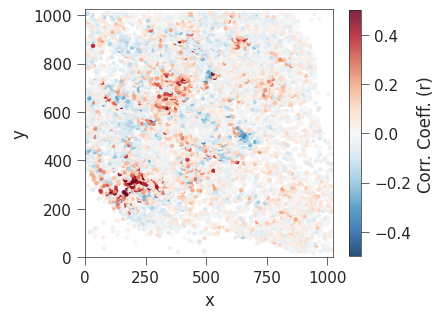

fish # jy-241203-f3 :  t2-stimR
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S6e-t2-stimR


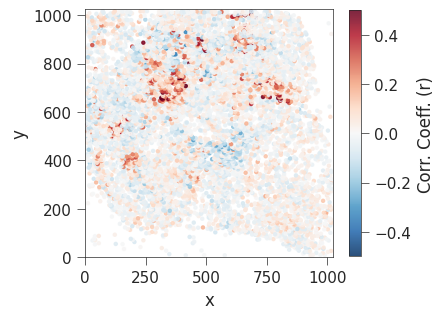

In [ ]:
subpanel = 'S6e'

rep_exp_ffile = ['jy-241203-f3,t1-stimL','jy-241203-f3,t2-stimR']

for rep_exp in rep_exp_ffile:
  rep_exp, rep_ffile = rep_exp.split(',')
  for exp, ffile, plane_num, trial_num in zip(experiments[:], fcn_files[:], planeNum[:], trialNum[:]):
    if exp != rep_exp or ffile != rep_ffile: continue
    load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'
    print("fish #", exp, ': ', ffile)

    # load processed 2p info
    data = np.load(load_path+'neuron_details.npz', allow_pickle=True)
    traces_Z, xs, ys, zs = data['traces_Z'], data['xs'], data['ys'], data['zs']
    # load stimulus
    data = np.load(load_path+'regressors.npz', allow_pickle=True)
    stimuli = data['stimuli']

    # Load correlation data for ROI coloring
    data = np.load(output_path+'pearson_corr.npz', allow_pickle=True)
    corr = data['corr']
    # print(np.shape(corr), np.shape(corr[0]))
    corr_coeffs = corr[2] # correlation to swim

    ## Plot ROI locations colored by correlation coefficient
    fig, ax = plt.subplots(1, 1, figsize=(4,4))
    scatter = ax.scatter(xs, ys, c=corr_coeffs, cmap='RdBu_r', marker='o', s=5, alpha=0.85, vmin=-0.5, vmax=0.5)
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_xlim(0,1024); ax.set_ylim(0,1024)
    # ax.set_title('ROI Locations - Colored by Correlation Coefficient')
    ax.set_aspect('equal')

    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax, label='Corr. Coeff. (r)',shrink=0.8)

    print(figure_path+subpanel+f'-{rep_ffile}')
    plt.savefig(figure_path+subpanel+f'-{rep_ffile}.pdf',bbox_inches='tight')
    plt.show()

    # save source data into csv
    series_dict = {'x': xs, 'y': ys, 'corr': corr_coeffs}
    df = pd.DataFrame(series_dict)
    df.to_csv(csv_path+subpanel+f'-{rep_ffile}.csv', index=False)

# S6f - example single neuron traces

fish # jy-241203-f2 :  t3-stimR
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/S6f


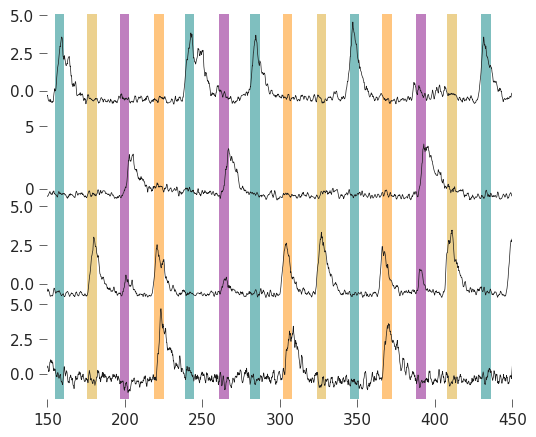

In [19]:
subpanel = 'S6f'

rep_exp_ffile = ['jy-241203-f2,t3-stimR']
samples = [] # for csv saving

pre, stim_dur, post = [sec*resample_Hz for sec in [5, 6, 14]] # baseline/stim on/ITI
off = 3*resample_Hz # potential response window to offset of stimulus
trial_len = pre+stim_dur+post

for rep_exp in rep_exp_ffile:
  rep_exp, rep_ffile = rep_exp.split(',')
  for exp, ffile, plane_num, trial_num in zip(experiments[6:], fcn_files[6:], planeNum[6:], trialNum[6:]):
    if exp != rep_exp or ffile != rep_ffile: continue
    load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'
    print("fish #", exp, ': ', ffile)

    # load processed data
    data = np.load(load_path+'neuron_details.npz', allow_pickle=True)
    traces_Z = data['traces_Z']
    # load stimulus onsets
    with open(load_path+'stim_ON.pkl', 'rb') as f:
      stim_on = pickle.load(f) # len(stim_names) x [n for f in trial_num]
    # load correlation coefficients
    data = np.load(output_path+'pearson_corr.npz',allow_pickle=True)
    corr = data['corr']

    # make time in sec
    frame_num = traces_Z.shape[1]
    time_sec = np.arange(frame_num)/resample_Hz

    #  vis
    fig, axs = plt.subplots(len(stim_names),1,figsize=(6,5))
    for id in range(len(stim_names)):
      max_corr = np.max(corr[id]); max_cell = np.argmax(corr[id])
      plt.subplot(len(stim_names),1,id+1)
      plt.plot(time_sec,traces_Z[max_cell], 'k',lw=0.5); samples.append(traces_Z[max_cell])
      ylim = plt.ylim(); sns.despine(bottom=True, left=True)
      if id != len(stim_names)-1: plt.xticks([])
      for j in range(len(stim_names)):
        on_frames = [on/resample_Hz for on in stim_on[j]]
        off_frames = [(on+stim_dur)/resample_Hz for on in stim_on[j]]
        for on, off in zip(on_frames,off_frames): plt.axvspan(on,off,facecolor=stim_colorz[j],alpha=0.5,edgecolor='none')
      plt.xlim(150,450)
    plt.subplots_adjust(hspace=0)
    print(figure_path+subpanel)
    # plt.savefig(figure_path+subpanel+'.pdf',bbox_inches='tight')
    plt.show()

    # save source data into csv - for time series, save out the visible part
    ST, ED = 0, traces_Z.shape[1]/resample_Hz; st, ed = 150, 450; fps = resample_Hz

    series_dict = {}
    for i, sample in enumerate(samples):
      col_name = f"cell_{i+1}"
      series_dict[col_name] = pd.Series(sample[(st-ST)*fps:(ed-ST)*fps])  # auto-fills NaN

    for i, stim_name in enumerate(stim_names):
      col_name = f"{stim_name}_on"; series_dict[col_name] = pd.Series([on/resample_Hz for on in stim_on[i]])
      col_name = f"{stim_name}_off"; series_dict[col_name] = pd.Series([(on+stim_dur)/resample_Hz for on in stim_on[i]])

    df = pd.DataFrame(series_dict)
    df.to_csv(csv_path+subpanel+'.csv', index=False)

# S6g - example rastermap

In [ ]:
!pip install rastermap
from rastermap import Rastermap, utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.5/90.5 kB 4.1 MB/s eta 0:00:00


fish # jy-241203-f3 :  t1-stimL
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S6g


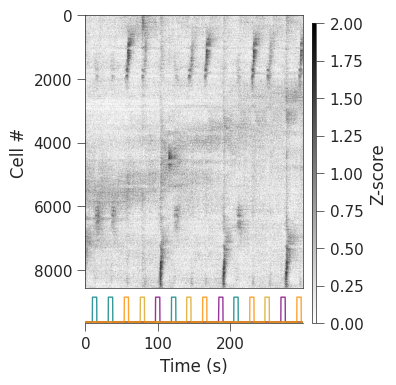

,cell_0,cell_1,cell_2,cell_3,cell_4,cell_5,cell_6,cell_7,cell_8,cell_9,...,cell_8569,cell_8570,cell_8571,cell_8572,cell_8573,cell_8574,stim_1,stim_2,stim_3,stim_4
0,2.170527,2.994028,-0.897439,-0.190852,0.649606,1.047648,0.926296,-0.378256,-1.087892,-0.540324,...,0.316271,-1.362572,-0.860225,-0.303307,-0.522359,0.258408,0.0,0.0,0.0,0.0
1,2.015391,2.863068,-1.209546,-0.186766,0.639246,1.141534,0.906751,-0.330528,-1.144961,-0.671148,...,0.069027,-1.115542,-0.790740,-0.079282,-0.504577,0.233936,0.0,0.0,0.0,0.0
2,1.831679,3.107761,-1.246844,-0.164125,0.900520,0.976162,0.308929,-0.390003,-1.110781,-0.505827,...,-0.490449,-1.011911,-0.814708,0.395014,-0.430306,0.611710,0.0,0.0,0.0,0.0
3,1.610961,3.349323,-1.246885,-0.233021,0.948607,0.818500,-0.189424,-0.411661,-1.132766,-0.449802,...,-0.908240,-0.939542,-0.876655,0.702423,-0.389629,0.675098,0.0,0.0,0.0,0.0
4,1.443380,3.425242,-1.246925,-0.492476,0.614763,0.757244,-0.410192,-0.334867,-1.237249,-0.679960,...,-1.125995,-0.764292,-0.974994,0.627660,-0.399693,0.213489,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,-1.032467,-0.766418,1.214585,-0.468763,-0.789797,0.473302,-1.343439,0.073676,2.628580,0.866266,...,-0.058610,-2.016949,-1.015370,-0.049538,0.762371,-0.302050,0.0,0.0,0.0,0.0
2996,-1.063108,-0.766429,1.214545,-0.552947,-0.688886,0.285728,-1.134386,0.094740,2.331311,0.932696,...,-0.069417,-2.071060,-0.864257,-0.072106,0.681986,-0.417860,0.0,0.0,0.0,0.0
2997,-1.246864,-0.766441,1.192886,-0.672415,-0.670621,0.113959,-0.990507,0.092617,1.766151,0.864397,...,0.027645,-1.996176,-0.729556,-0.034570,0.712166,-0.598076,0.0,0.0,0.0,0.0
2998,-1.446435,-0.766452,1.119492,-0.759294,-0.518372,0.168743,-0.877906,-0.020174,1.095747,0.859618,...,-0.003665,-1.951438,-0.700349,-0.450511,0.764484,-0.776113,0.0,0.0,0.0,0.0


In [ ]:
subpanel = 'S6g'

rep_exp_ffile = ['jy-241203-f3,t1-stimL'] #

pre, stim_dur, post = [sec*resample_Hz for sec in [5, 6, 14]] # baseline/stim on/ITI
off = 3*resample_Hz # potential response window to offset of stimulus
trial_len = pre+stim_dur+post

for rep_exp in rep_exp_ffile:
  rep_exp, rep_ffile = rep_exp.split(',')
  for exp, ffile, plane_num, trial_num in zip(experiments[:], fcn_files[:], planeNum[:], trialNum[:]):
    if exp != rep_exp or ffile != rep_ffile: continue
    load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'
    print("fish #", exp, ': ', ffile)

    # load processed 2p info
    data = np.load(load_path+'neuron_details.npz', allow_pickle=True)
    traces_Z, xs, ys, zs = data['traces_Z'], data['xs'], data['ys'], data['zs']
    # load stimulus
    data = np.load(load_path+'regressors.npz', allow_pickle=True)
    stimuli = data['stimuli']

    # make time in sec
    frame_num = traces_Z.shape[1]
    time_sec = np.arange(frame_num)/resample_Hz

    # crop the last 300 sec
    traces_Z = traces_Z[:,-400*resample_Hz:-100*resample_Hz]
    time_sec = time_sec[:300*resample_Hz];

    # vis
    # fit rastermap to pca clustering
    spks = np.array(traces_Z) # neurons x timepoints
    model = Rastermap(n_clusters=10, n_PCs=10, time_lag_window=10, locality=0.5,\
                      grid_upsample=10).fit(spks)
    clu_neuron = model.embedding; isort = model.isort # indices to sort traces into cluster

    # plot
    fig, axs = plt.subplots(2,1, figsize=(3,4), gridspec_kw={'height_ratios':[10,1]}) # 'width_ratios': [10,1]
    im = axs[0].imshow(spks[isort, :], cmap="gray_r", vmin=0, vmax=2, aspect="auto")
    axs[0].set_xticks([]); axs[0].set_ylabel('Cell #');
    fig.subplots_adjust(right=0.85,wspace=0.05)
    cbar_ax = fig.add_axes([0.88,0.11,0.015,0.75])  # [left, bottom, width, height]
    cbar = fig.colorbar(im, cax=cbar_ax, label='Z-score');
    for idx, stim in enumerate(stimuli):
      axs[1].plot(time_sec,stim[-400*resample_Hz:-100*resample_Hz], color=stim_colorz[idx], linewidth=1, alpha=0.8)
    axs[1].spines['top'].set_visible(False); axs[1].spines['right'].set_visible(False)
    axs[1].spines['left'].set_visible(False); axs[1].set_xlabel('Time (s)')
    axs[1].set_yticks([]); axs[1].set_xlim(0,time_sec[-1])
    plt.subplots_adjust(hspace=0.05)
    print(figure_path+subpanel)
    plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
    plt.show()

    # save source data into csv
    series_dict = {}
    for idx, trace in enumerate(spks[isort, :]): series_dict['cell_'+str(idx)] = trace
    for idx, stim in enumerate(stimuli): series_dict['stim_'+str(idx+1)] = pd.Series(stim[-400*resample_Hz:-100*resample_Hz])

    df = pd.DataFrame(series_dict)
    display(df)
    df.to_csv(csv_path+subpanel+'.csv', index=False)

# S6h-i - example heatmap and mean traces overlaid

In [ ]:
# Install required package
!pip install upsetplot
from upsetplot import from_contents, UpSet

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for upsetplot: filename=upsetplot-0.9.0-py3-none-any.whl size=24864 sha256=32eec26c8efa421b00c0693e728ccf589c78e99ecac6b2758e272e6591955fb4
  Stored in directory: /root/.cache/pip/wheels/5d/7a/54/1460364da0fe4e17c256b7a28191fa373d81292fcf73a4ddb8
Successfully built upsetplot


fish # jy-241203-f3 :  t1-stimL
responsive celss n = [1084, 2122, 1656, 1779]

 any responsive cells
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S6h


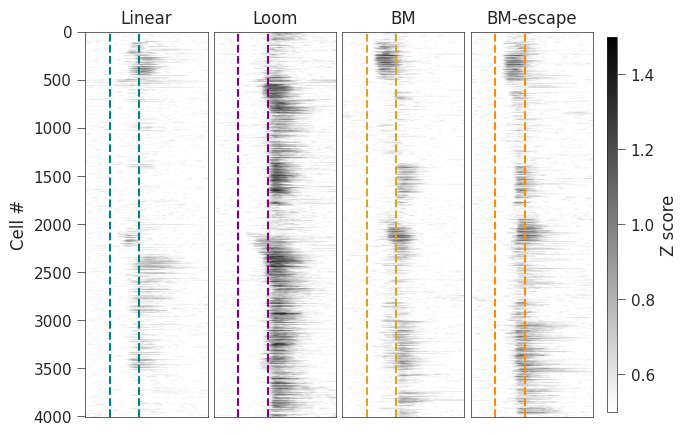

,stim1_1,stim1_2,stim1_3,stim1_4,stim1_5,stim1_6,stim1_7,stim1_8,stim1_9,stim1_10,...,stim4_3997,stim4_3998,stim4_3999,stim4_4000,stim4_4001,stim4_4002,stim4_4003,stim4_4004,stim4_4005,stim4_4006
0,-0.129070,-0.148565,0.090942,0.006292,-0.284096,0.011631,-0.330761,-0.104533,0.788766,0.334302,...,0.480110,-0.267319,0.191295,-0.104274,-0.207519,-0.262468,-0.069748,-0.500061,0.609348,-0.207259
1,-0.072036,-0.060570,0.133084,0.123254,-0.266099,-0.039987,-0.320165,-0.127593,0.776854,0.310069,...,0.638530,-0.213081,0.222741,-0.155428,0.042776,-0.235551,-0.071763,-0.427101,0.718438,-0.410235
2,-0.046806,-0.091279,0.116316,0.233048,-0.254701,-0.185937,-0.263717,-0.190968,0.697655,0.248482,...,0.806011,-0.166268,0.205602,-0.176066,0.243075,-0.240834,-0.043308,-0.397945,0.724067,-0.530695
3,-0.023859,-0.107132,0.076738,0.308890,-0.271748,-0.333519,-0.248687,-0.225481,0.640648,0.164693,...,0.815699,-0.105107,0.142753,-0.112939,0.271506,-0.272317,0.007557,-0.387702,0.570627,-0.547469
4,0.012269,-0.059788,0.057594,0.291838,-0.323128,-0.453079,-0.277040,-0.224709,0.625073,0.080718,...,0.756745,0.007543,0.111418,-0.070970,0.212982,-0.257524,0.075874,-0.403795,0.353283,-0.522346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,0.016909,-0.057078,0.365931,-0.075187,-0.221620,-0.420857,0.312961,-0.521719,-0.324905,-0.396399,...,0.303383,-0.286712,-0.266623,0.133302,-0.130161,-0.073648,0.002748,0.499338,-0.009082,-0.418749
246,-0.019855,-0.172698,0.355514,-0.099154,-0.116361,-0.431228,0.319570,-0.556384,-0.419049,-0.421189,...,0.355257,-0.256166,-0.325257,0.260981,-0.064841,-0.041507,-0.051858,0.386958,-0.067557,-0.378371
247,-0.000378,-0.306227,0.349060,-0.102093,-0.018029,-0.413968,0.337830,-0.521355,-0.446646,-0.465849,...,0.355397,-0.229926,-0.410357,0.321830,-0.000413,-0.014346,-0.095341,0.287801,-0.170612,-0.179678
248,0.019044,-0.397455,0.337087,-0.100478,0.021185,-0.389635,0.333778,-0.465162,-0.392559,-0.541507,...,0.345680,-0.247410,-0.457373,0.333066,0.027096,0.050286,-0.104024,0.139134,-0.308649,0.145135


total (unique) n = 4006
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S6i


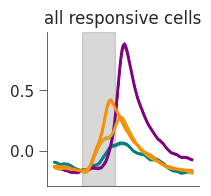

,cell_1_to_Linear,cell_2_to_Linear,cell_3_to_Linear,cell_4_to_Linear,cell_5_to_Linear,cell_6_to_Linear,cell_7_to_Linear,cell_8_to_Linear,cell_9_to_Linear,cell_10_to_Linear,...,cell_3997_to_BM-escape,cell_3998_to_BM-escape,cell_3999_to_BM-escape,cell_4000_to_BM-escape,cell_4001_to_BM-escape,cell_4002_to_BM-escape,cell_4003_to_BM-escape,cell_4004_to_BM-escape,cell_4005_to_BM-escape,cell_4006_to_BM-escape
0,-0.129070,-0.148565,0.090942,0.006292,-0.284096,0.011631,-0.330761,-0.104533,0.788766,0.334302,...,0.480110,-0.267319,0.191295,-0.104274,-0.207519,-0.262468,-0.069748,-0.500061,0.609348,-0.207259
1,-0.072036,-0.060570,0.133084,0.123254,-0.266099,-0.039987,-0.320165,-0.127593,0.776854,0.310069,...,0.638530,-0.213081,0.222741,-0.155428,0.042776,-0.235551,-0.071763,-0.427101,0.718438,-0.410235
2,-0.046806,-0.091279,0.116316,0.233048,-0.254701,-0.185937,-0.263717,-0.190968,0.697655,0.248482,...,0.806011,-0.166268,0.205602,-0.176066,0.243075,-0.240834,-0.043308,-0.397945,0.724067,-0.530695
3,-0.023859,-0.107132,0.076738,0.308890,-0.271748,-0.333519,-0.248687,-0.225481,0.640648,0.164693,...,0.815699,-0.105107,0.142753,-0.112939,0.271506,-0.272317,0.007557,-0.387702,0.570627,-0.547469
4,0.012269,-0.059788,0.057594,0.291838,-0.323128,-0.453079,-0.277040,-0.224709,0.625073,0.080718,...,0.756745,0.007543,0.111418,-0.070970,0.212982,-0.257524,0.075874,-0.403795,0.353283,-0.522346
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,0.016909,-0.057078,0.365931,-0.075187,-0.221620,-0.420857,0.312961,-0.521719,-0.324905,-0.396399,...,0.303383,-0.286712,-0.266623,0.133302,-0.130161,-0.073648,0.002748,0.499338,-0.009082,-0.418749
246,-0.019855,-0.172698,0.355514,-0.099154,-0.116361,-0.431228,0.319570,-0.556384,-0.419049,-0.421189,...,0.355257,-0.256166,-0.325257,0.260981,-0.064841,-0.041507,-0.051858,0.386958,-0.067557,-0.378371
247,-0.000378,-0.306227,0.349060,-0.102093,-0.018029,-0.413968,0.337830,-0.521355,-0.446646,-0.465849,...,0.355397,-0.229926,-0.410357,0.321830,-0.000413,-0.014346,-0.095341,0.287801,-0.170612,-0.179678
248,0.019044,-0.397455,0.337087,-0.100478,0.021185,-0.389635,0.333778,-0.465162,-0.392559,-0.541507,...,0.345680,-0.247410,-0.457373,0.333066,0.027096,0.050286,-0.104024,0.139134,-0.308649,0.145135



(repeat) cells responsive to each stim
total n = 6641
n = [1084, 2122, 1656, 1779]


In [ ]:
rep_exp_ffile = ['jy-241203-f3,t1-stimL']
from itertools import accumulate

pre, stim_dur, post = [sec*resample_Hz for sec in [5, 6, 14]] # baseline/stim on/ITI
off = 3*resample_Hz # potential response window to offset of stimulus
trial_len = pre+stim_dur+post

for rep_exp in rep_exp_ffile:
  rep_exp, rep_ffile = rep_exp.split(',')
  for exp, ffile, plane_num, trial_num in zip(experiments[7:], fcn_files[7:], planeNum[7:], trialNum[7:]):
    if exp != rep_exp or ffile != rep_ffile: continue
    load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'
    print("fish #", exp, ': ', ffile)
    # (1) get cell respnse metrics
    data = np.load(output_path+'dF_ttest.npz', allow_pickle=True)
    Pval_long = data['Pval_long']
    # categorize responsive or not
    all_profile = np.array([p<0.05 for p in Pval_long]) # resp profile of all cells
    resp_arr = all_profile[:,np.any(all_profile,axis=0)] # resp profiles of all responsive cells
    # get cell ids
    cell_ids = np.arange(Pval_long.shape[1])
    resp_ids = [cell_ids[p<0.05] for p in Pval_long] # list of responsive cell id for each stim
    cell_arr = np.unique(np.concatenate(resp_ids)) # list of cell id resp to any stim

    print('responsive celss n =', [len(c) for c in resp_ids])
    # compute & visualize overlap of response
    tmp = {stim: cells for stim, cells in zip(stim_names, resp_ids)}
    overlap = from_contents(tmp); # UpSet(overlap, subset_size="count").plot();
    # path = figure_path; fig_name = "resp_overlap_ttest"+rep_exp+"-"+rep_ffile
    # plt.savefig(path+fig_name+".pdf",bbox_inches='tight')
    plt.show()

    # load PSTHs
    with open(output_path+'PSTHs.pkl', 'rb') as f:
      PSTHs = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]
    # (2) get psth from responsive cells

    print('\n any responsive cells')
    resp_raster = [[] for i in range(len(stim_names))] # use cell_arr # non-repeating
    for id in range(len(stim_names)):
      for icell in cell_arr: resp_raster[id].append(np.nanmean(PSTHs[icell][id],axis=0))
    resp_raster = np.array(resp_raster); #print(resp_raster.shape)

    subpanel = 'S6h'
    #  rastermap
    fig,_ = plt.subplots(1,len(stim_names),figsize=[7,5]) # [10,6]
    for istim in range(len(stim_names)):
      box = np.array(resp_raster[istim])
      plt.subplot(1,len(stim_names),istim+1)
      im = plt.imshow(box, cmap="gray_r", vmin=0.5, vmax=1.5, aspect="auto")
      plt.title(stim_names[istim])
      for line in [pre, pre+stim_dur]: plt.axvline(line,c=stim_colorz[istim],linestyle='--'); plt.xticks([])
      if istim==0: plt.ylabel('Cell #')
      if istim>0: plt.yticks([])
    fig.subplots_adjust(right=0.85,wspace=0.05)
    cbar_ax = fig.add_axes([0.87,0.12,0.015,0.75])  # [left, bottom, width, height]
    cbar = fig.colorbar(im, cax=cbar_ax, label='Z score'); # cbar.ax.tick_params(left=False, labelleft=False)  # Remove ticks and labels
    print(figure_path+subpanel)
    plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
    plt.show()

    # save source data into csv
    series_dict = {}
    for istim, sample in enumerate(resp_raster):
      for i, sample in enumerate(resp_raster[istim]):
        col_name = f"stim{istim+1}_{i+1}"
        series_dict[col_name] = sample
    df = pd.DataFrame(series_dict)
    display(df)
    df.to_csv(csv_path+subpanel+f".csv", index=False)

    print(f"total (unique) n = {len(cell_arr)}")
    subpanel = 'S6i'
    # mean psth - together
    plt.figure(figsize=[9,2]); #[12,3]
    curves = [np.nanmean(resp_raster[id],axis=0) for id in range(len(stim_names))]
    ymin, ymax = np.min(curves), np.max(curves)
    for id in range(len(stim_names)):
      plt.subplot(1,len(stim_names),id+1);
      for i in range(len(stim_names)):
        tmp = np.array(resp_raster[i]); tmp.shape
        plt.plot(np.nanmean(tmp,axis=0),c=stim_colorz[i],lw=2)
        plt.fill_between(np.arange(trial_len), np.nanmean(tmp,axis=0)+stats.sem(tmp,axis=0,nan_policy='omit'), \
                          np.nanmean(tmp,axis=0)-stats.sem(tmp,axis=0,nan_policy='omit'),color=stim_colorz[i],alpha=0.8)
      # for line in [pre, pre+stim_dur]: plt.axvline(line,c='gray',linestyle='--',alpha=0.7,lw=1.5)
      plt.axvspan(pre, pre+stim_dur, color='gray', alpha=0.3)
      sns.despine(); plt.xticks([]); plt.ylim(ymin-0.1*(ymax-ymin),ymax+0.1*(ymax-ymin))
      break # only need one
    plt.title("all responsive cells")
    print(figure_path+subpanel)
    plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
    plt.show()

    # save source data into csv
    series_dict = {}
    for istim, sample in enumerate(resp_raster):
      for icell, psth in enumerate(sample):
        col_name = f"cell_{icell+1}_to_{stim_names[istim]}"
        series_dict[col_name] = pd.Series(psth)

    df = pd.DataFrame(series_dict)
    display(df)
    df.to_csv(csv_path+subpanel+'.csv', index=False)

    print('\n(repeat) cells responsive to each stim')
    resp_raster = [[[] for i in range(len(stim_names))] for j in range(len(stim_names))] # use resp_ids # repeating
    for id in range(len(stim_names)):
        for icell in resp_ids[id]:
          for i in range(len(stim_names)): resp_raster[id][i].append(np.nanmean(PSTHs[icell][i],axis=0))

    print(f"total n = {list(accumulate([len(ids) for ids in resp_ids]))[-1]}")
    print(f"n = {[len(ids) for ids in resp_ids]}")

# S6j - summary response overlap plot

In [ ]:
# Install required package
!pip install upsetplot
from upsetplot import from_contents, UpSet

Analyzing neural response overlap across all fish
  Responsive cells: [432, 987, 508, 683]
  Responsive cells: [136, 261, 155, 214]
  Responsive cells: [80, 210, 115, 102]
  Responsive cells: [57, 134, 113, 118]
  Responsive cells: [129, 468, 194, 348]
  Responsive cells: [214, 504, 231, 384]
  Responsive cells: [81, 766, 107, 149]
  Responsive cells: [480, 1225, 859, 1037]
  Responsive cells: [415, 1970, 778, 1211]
  Responsive cells: [252, 993, 356, 303]
  Responsive cells: [353, 954, 625, 882]
  Responsive cells: [316, 1140, 438, 725]
  Responsive cells: [91, 689, 107, 70]
  Responsive cells: [197, 588, 317, 446]
  Responsive cells: [116, 241, 114, 161]
  Responsive cells: [39, 71, 68, 35]
  Responsive cells: [75, 128, 102, 133]
  Responsive cells: [120, 173, 122, 201]
  Responsive cells: [31, 40, 26, 35]
  Responsive cells: [151, 460, 201, 343]
  Responsive cells: [214, 528, 241, 427]
  Responsive cells: [56, 260, 122, 109]
  Responsive cells: [91, 162, 117, 126]
  Responsive cells

/tmp/ipykernel_11324/1616550820.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


<Figure size 1200x800 with 0 Axes>

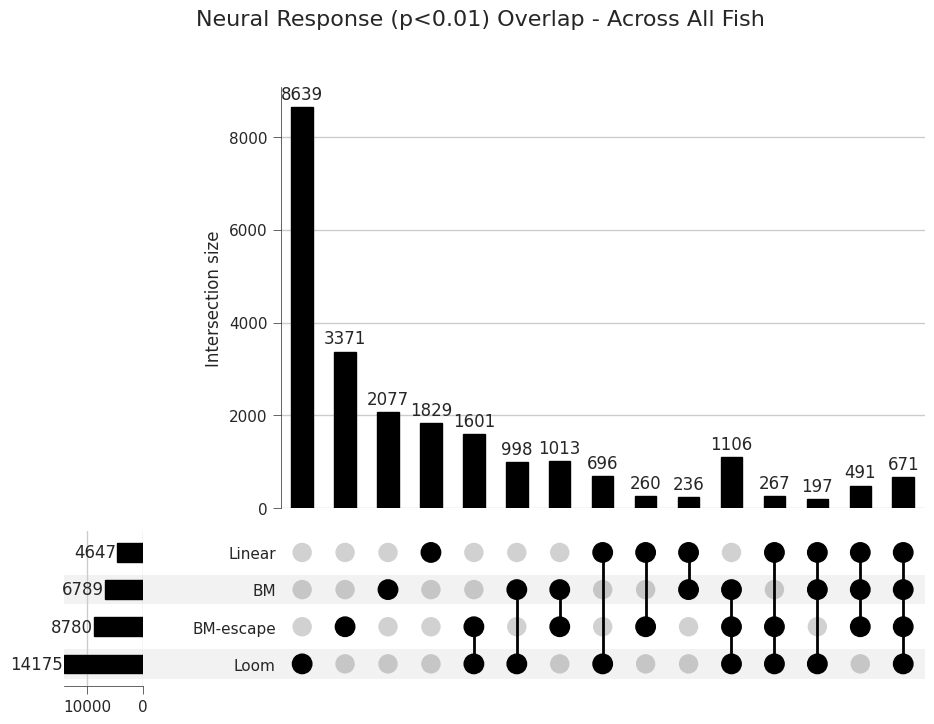


SUMMARY STATISTICS:
Total unique responsive cells across all fish: 23452
Total fish analyzed: 12
Average responsive cells per stimulus: 9125.8
Note: Could not save overlap statistics CSV file

Analysis complete!


In [ ]:
subpanel = 'S6j'

# Initialize containers for across-fish responsive cell analysis
across_fish_resp_ids = [[] for _ in range(len(stim_names))]
all_fish_cells = []  # to track all unique cell identifiers

print("Analyzing neural response overlap across all fish")
print("=" * 50)

for exp, ffile, plane_num, trial_num in zip(experiments[:], fcn_files[:], planeNum[:], trialNum[:]):
    [t1, t2, t3, t4] = [int(t) for t in trial_num.split(' ')]
    load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'
    # print("fish #", exp, ': ', ffile)

    # (1) get cell response metrics
    data = np.load(output_path+'dF_ttest.npz', allow_pickle=True)
    Pval_long = data['Pval_long']

    # categorize responsive or not
    all_profile = np.array([p<0.05 for p in Pval_long])

    # get cell ids with fish identifier
    cell_ids = np.arange(Pval_long.shape[1])

    # Create unique cell identifiers across fish: "fish_cellID"
    unique_cell_ids = [f"{exp}_{cell_id}" for cell_id in cell_ids]

    # Get responsive cell IDs for each stimulus (with fish identifier)
    resp_ids_this_fish = [
        [f"{exp}_{cell_id}" for cell_id in cell_ids[p<0.01]]
        for p in Pval_long
    ]

    # Append to across-fish responsive cell lists
    for stim_idx, resp_cells in enumerate(resp_ids_this_fish):
        across_fish_resp_ids[stim_idx].extend(resp_cells)

    # Print per-fish statistics
    print(f"  Responsive cells: {[len(cells) for cells in resp_ids_this_fish]}")

print("\n" + "=" * 50)
print('Across-fish responsive cells n =', [len(cells) for cells in across_fish_resp_ids])

# Create UpSet plot for across-fish data - ensure unique cell lists per stimulus
across_fish_overlap_dict = {stim: list(set(cells)) for stim, cells in zip(stim_names, across_fish_resp_ids)}

# Debug: print lengths before and after deduplication
print("\nDeduplication check:")
for stim, cells in zip(stim_names, across_fish_resp_ids):
    unique_cells = list(set(cells))
    print(f"{stim}: {len(cells)} -> {len(unique_cells)} unique cells")

across_fish_overlap = from_contents(across_fish_overlap_dict)

# Create and save the plot
plt.figure(figsize=(12, 8))
upset_plot = UpSet(across_fish_overlap, subset_size="count", show_counts=True,
                   element_size=40, intersection_plot_elements=10)
upset_plot.plot()
plt.suptitle('Neural Response (p<0.01) Overlap - Across All Fish', fontsize=16, y=0.98)
plt.tight_layout()
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

# Print summary statistics
total_responsive_cells = len(np.unique(np.concatenate(across_fish_resp_ids)))
total_fish = len(set([exp for exp, _, _, _ in zip(experiments[:], fcn_files[:], planeNum[:], trialNum[:])]))

print(f"\nSUMMARY STATISTICS:")
print(f"Total unique responsive cells across all fish: {total_responsive_cells}")
print(f"Total fish analyzed: {total_fish}")
print(f"Average responsive cells per stimulus: {np.mean([len(cells) for cells in across_fish_resp_ids]):.1f}")

# Optional: Save the overlap statistics
try:
    overlap_stats = across_fish_overlap.to_frame().reset_index()
    overlap_stats.to_csv(csv_path + 'overlap_stats_across_fish.csv')
    print(f"Overlap statistics saved to: {csv_path}overlap_stats_across_fish.csv")
except:
    print("Note: Could not save overlap statistics CSV file")

print("\nAnalysis complete!")

# S6k

## mean traces to all stimulus (per fish and overlaid responsive cells)

In [ ]:
# Install required package
!pip install upsetplot
from upsetplot import from_contents, UpSet

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for upsetplot: filename=upsetplot-0.9.0-py3-none-any.whl size=24864 sha256=29b5ba659537a0bd782d1475e8bc8e47c3c6ec6aeadc6b440b78cce1043e582e
  Stored in directory: /root/.cache/pip/wheels/5d/7a/54/1460364da0fe4e17c256b7a28191fa373d81292fcf73a4ddb8
Successfully built upsetplot



fish # jy-241126-f2 :  t2-stimR
any responsive cells

fish # jy-241126-f4 :  t1-stimL
any responsive cells

fish # jy-241126-f4 :  t2-stimR
any responsive cells

fish # jy-241126-f4 :  t3-stimL
any responsive cells

fish # jy-241203-f2 :  t1-stimL
any responsive cells

fish # jy-241203-f2 :  t2-stimR
any responsive cells

fish # jy-241203-f2 :  t3-stimR
any responsive cells

fish # jy-241203-f3 :  t1-stimL
any responsive cells

fish # jy-241203-f3 :  t2-stimR
any responsive cells

fish # jy-241203-f3 :  t3-stimL
any responsive cells

fish # jy-241204-f3 :  t1-stimL
any responsive cells

fish # jy-241204-f3 :  t2-stimR
any responsive cells

fish # jy-241204-f3 :  t3-stimL
any responsive cells

fish # jy-241211-f1 :  t1-stimL
any responsive cells

fish # jy-241211-f1 :  t2-stimR
any responsive cells

fish # jy-241211-f1 :  t3-stimL
any responsive cells

fish # jy-241211-f2 :  t1-stimL
any responsive cells

fish # jy-241211-f2 :  t2-stimL
any responsive cells

fish # jy-241211-f2 :  t3-s

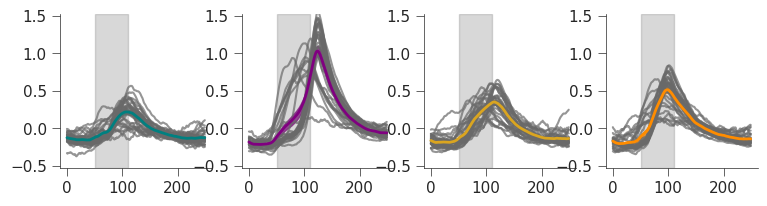

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S6k-all resp


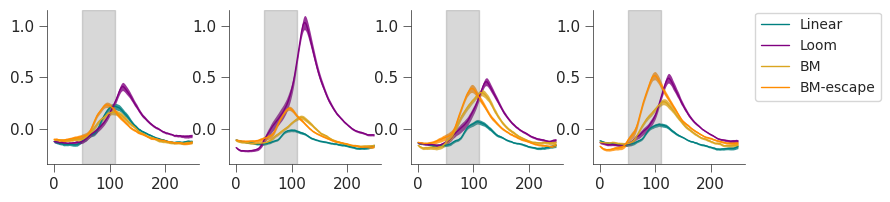

In [ ]:
subpanel = 'S6k'

pre, stim_dur, post = [sec*resample_Hz for sec in [5, 6, 14]] # baseline/stim on/ITI
off = 3*resample_Hz # potential response window to offset of stimulus
trial_len = pre+stim_dur+post

# visualize psth of responsive cells per fish
across_fish_raster = [[[] for i in range(len(stim_names))] for j in range(len(stim_names))]
across_fish_cell_cnt = [[] for i in range(len(stim_names))]; fish_cnt = []

for exp, ffile, plane_num, trial_num in zip(experiments[:], fcn_files[:], planeNum[:], trialNum[:]):
  [t1, t2, t3, t4] = [int(t) for t in trial_num.split(' ')]
  load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'
  print("\nfish #", exp, ': ', ffile)

  # (1) get cell respnse metrics
  data = np.load(output_path+'dF_ttest.npz', allow_pickle=True)
  Pval_long = data['Pval_long']
  # categorize responsive or not
  all_profile = np.array([p<0.05 for p in Pval_long]) # resp profile of all cells
  resp_arr = all_profile[:,np.any(all_profile,axis=0)] # resp profiles of all responsive cells
  # get cell ids
  cell_ids = np.arange(Pval_long.shape[1])
  resp_ids = [cell_ids[p<0.05] for p in Pval_long] # list of responsive cell id for each stim
  cell_arr = np.unique(np.concatenate(resp_ids)) # list of cell id resp to any stim

  # print('responsive celss n =', [len(c) for c in resp_ids])
  # compute & visualize overlap of response
  tmp = {stim: cells for stim, cells in zip(stim_names, resp_ids)}
  overlap = from_contents(tmp);

  # load PSTHs
  with open(output_path+'PSTHs.pkl', 'rb') as f:
    PSTHs = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]
  # (2) get psth from responsive cells
  print('any responsive cells')
  resp_raster = [[] for i in range(len(stim_names))] # use cell_arr # non-repeating
  for id in range(len(stim_names)):
    for icell in cell_arr: resp_raster[id].append(np.nanmean(PSTHs[icell][id],axis=0))
  resp_raster = np.array(resp_raster); #print(resp_raster.shape)

  # print(f"total (unique) n = {len(cell_arr)}")
  # print('(repeat) cells responsive to each stim')
  resp_raster = [[[] for i in range(len(stim_names))] for j in range(len(stim_names))] # use resp_ids # repeating
  for id in range(len(stim_names)):
      for icell in resp_ids[id]:
        for i in range(len(stim_names)): resp_raster[id][i].append(np.nanmean(PSTHs[icell][i],axis=0))

  # print(f"total n = {list(accumulate([len(ids) for ids in resp_ids]))[-1]}")
  # print(f"n = {[len(ids) for ids in resp_ids]}")

  # (3) append to across fish stats
  for id in range(len(stim_names)):
    for i in range(len(stim_names)): across_fish_raster[id][i].append(np.nanmean(resp_raster[id][i],axis=0))
  for id in range(len(stim_names)): across_fish_cell_cnt[id].append(len(resp_ids[id]))
  fish_cnt.append(exp)

  # break

# across fish summary
print("\nSUMMARY:")
across_fish_raster = np.array(across_fish_raster); # repsonsive type x stim type x fish x trial len
print(f"across {across_fish_raster.shape[2]} fish, {np.sum(across_fish_cell_cnt)} cells")
print(f"n = {[sum(across_fish_cell_cnt[i]) for i in range(len(stim_names))]}") # stim type x fish

# mean psth - with ind fish traces
plt.figure(figsize=[9,2]);
curves = [np.nanmean(across_fish_raster[id][id],axis=0) for id in range(len(stim_names))]
ymin, ymax = np.min(curves), np.max(curves)
for id in range(len(stim_names)):
  plt.subplot(1,len(stim_names),id+1);
  tmp = np.array(across_fish_raster[id][id])
  for t in tmp: plt.plot(t,c='dimgrey',alpha=0.7)
  plt.plot(np.nanmean(tmp,axis=0),c=stim_colorz[id],lw=2)
  plt.fill_between(np.arange(trial_len), np.nanmean(tmp,axis=0)+stats.sem(tmp,axis=0,nan_policy='omit'), \
                    np.nanmean(tmp,axis=0)-stats.sem(tmp,axis=0,nan_policy='omit'),color=stim_colorz[id],alpha=0.8)
  plt.axvspan(pre, pre+stim_dur, color='gray', alpha=0.3)
  sns.despine(); plt.ylim(ymin-0.25*(ymax-ymin),ymax+0.4*(ymax-ymin))
print(figure_path+subpanel+"-mean+ind")
plt.savefig(figure_path+subpanel+"-mean+ind.pdf",bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
for i, samples in enumerate(across_fish_raster):
  for ifish, psth in enumerate(samples[i]):
    col_name = f"{stim_names[i]}_{ifish+1}";
    series_dict[col_name] = pd.Series(psth)

df = pd.DataFrame(series_dict)
df.to_csv(csv_path+subpanel+'-mean+ind.csv', index=False)

# mean psth - together
plt.figure(figsize=[9,2]);
curves = [[np.nanmean(across_fish_raster[id][i],axis=0) for id in range(len(stim_names))] for i in range(len(stim_names))]
ymin, ymax = np.min(curves), np.max(curves)
for id in range(len(stim_names)):
  plt.subplot(1,len(stim_names),id+1);
  for i in range(len(stim_names)):
    tmp = np.array(across_fish_raster[id][i])
    plt.plot(np.nanmean(tmp,axis=0),c=stim_colorz[i],lw=1,label=stim_names[i])
    plt.fill_between(np.arange(trial_len), np.nanmean(tmp,axis=0)+stats.sem(tmp,axis=0,nan_policy='omit'), \
                      np.nanmean(tmp,axis=0)-stats.sem(tmp,axis=0,nan_policy='omit'),color=stim_colorz[i],alpha=0.8,lw=0)
  plt.axvspan(pre, pre+stim_dur, color='gray', alpha=0.3)
  sns.despine(); plt.ylim(ymin-0.1*(ymax-ymin),ymax+0.1*(ymax-ymin))
plt.legend(bbox_to_anchor=(1.05,1),markerscale=0.7,borderaxespad=0.2,fontsize=10)
print(figure_path+subpanel+"-all resp")
plt.savefig(figure_path+subpanel+"-all resp.pdf",bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
for id, samples in enumerate(across_fish_raster):
  for i, sample in enumerate(samples):
    for ifish, psth in enumerate(sample):
      col_name = f"{stim_names[id]}-responsive_cells_to_{stim_names[i]}_{ifish+1}";
      series_dict[col_name] = pd.Series(psth)
df = pd.DataFrame(series_dict)
df.to_csv(csv_path+subpanel+'-all resp.csv', index=False)

## normalized dots size time series

In [20]:
# load csv from Bonsai
path = '/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Imaging/Dots_do_stuff/Data/'
measures = pd.read_csv(path + 'stim_size_xy.csv', header=0)

monitor_area = measures.iloc[0,0]*measures.iloc[0,1]
stim_areas = np.array(measures.iloc[:,2])
xs = np.array(measures.iloc[:,3])
ys = np.array(measures.iloc[:,4])

In [21]:
# identify the frames for four stimuli
binary = (stim_areas != 0).astype(int)
diff = np.diff(binary, prepend=0, append=0)
onsets = np.where(diff == 1)[0][:4]; offsets = np.where(diff == -1)[0]
# Display results
for i, (start, end) in enumerate(zip(onsets, offsets)):
    print(f"stim {i+1}: onset = {start}, offset = {end-1}")
tmp = []
for i, (start, end) in enumerate(zip(onsets, offsets)): tmp.append(end-start)
print(f"mean fps {np.mean(tmp)/6:.2f} Hz")

diameter = np.sqrt(stim_areas/math.pi)

# translate x postion on screen to real life postion to fish
real_xs = (xs-1400)/(700-1400)*(71.3-6.6)+6.6
# get equation of line / monitor # y = a*x + b
a = (-71.3-75.6)/(71.3-6.6); b = 75.6-a*6.6
real_ys = a*real_xs + b

def resized(data,N):
    old_indices = np.linspace(0, len(data) - 1, len(data))
    new_indices = np.linspace(0, len(data) - 1, N)
    res = np.interp(new_indices, old_indices, data)
    return res

# crop the metrics into 4 stim and resample all to 6-sec stim at 10 Hz
new_Hz = 60; pre = 1*new_Hz; stim_dur = 6*new_Hz; post = 3*new_Hz;
new_time_base = pre+stim_dur+post

stim_size_px = {n:[] for n in stim_names}
stim_X_px = {n:[] for n in stim_names}; stim_Y_px = {n:[] for n in stim_names}

for i, (start, end) in enumerate(zip(onsets, offsets)):
  # print(stim_names[i])
  size_px = (stim_areas*binary)[start:end]
  size_px = np.concatenate([np.full(pre, 0), size_px, np.full(post, 0)])
  size_px_new = resized(size_px,new_time_base)
  # print(len(size_px), len(size_px_new))
  stim_size_px[stim_names[i]] = size_px_new

  X_px = (xs*binary)[start:end]
  X_px = np.concatenate([np.full(pre, 0), X_px, np.full(post, 0)])
  X_px_new = resized(X_px,new_time_base)
  # print(len(X_px), len(X_px_new))
  stim_X_px[stim_names[i]] = X_px_new

  Y_px = (ys*binary)[start:end]
  Y_px = np.concatenate([np.full(pre, 0), Y_px, np.full(post, 0)])
  Y_px_new = resized(Y_px,new_time_base)
  # # print(len(Y_px), len(Y_px_new))
  stim_Y_px[stim_names[i]] = Y_px_new

stim 1: onset = 223, offset = 580
stim 2: onset = 886, offset = 1244
stim 3: onset = 1522, offset = 1869
stim 4: onset = 2185, offset = 2527
mean fps 58.67 Hz


/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v8/subpanels/S6k


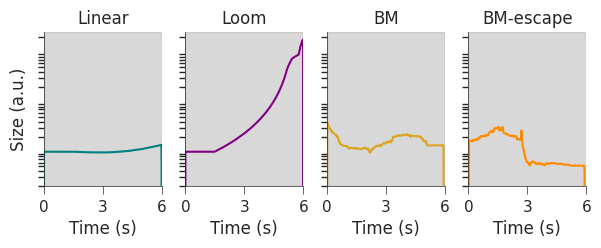

,Linear,Loom,BM,BM-escape
0,952.397329,2326.781302,1503.303840,596.490818
1,955.367279,2353.539232,1514.891486,590.480801
2,961.000000,2377.111853,1528.557596,593.131886
3,960.434057,2406.207012,1557.824708,594.000000
4,957.814691,2435.409015,1580.986644,590.919866
...,...,...,...,...
175,1345.529215,158849.954925,1326.000000,0.000000
176,1348.388982,165182.447412,442.737896,0.000000
177,1355.292154,171048.420701,0.000000,0.000000
178,1359.395659,176729.397329,0.000000,0.000000


In [29]:
subpanel = 'S6k'
# make time_sec relative to tap for plotting
rel_time = np.linspace(-1,9,10*60); rel_sec = np.round(rel_time,2)
# print("Stim size (px^2)")
values = stim_size_px
plt.figure(figsize=[7,2]);
for id, stim in enumerate((stim_names)):
  plt.subplot(1,len(stim_names),id+1);
  plt.plot(rel_sec,values[stim],c=stim_colorz[id])
  plt.axvspan(0, 6, color='gray', alpha=0.3)
  plt.xticks([0,3,6]); plt.xlabel('Time (s)')
  plt.yscale("log"); plt.ylim(200,250000)
  if id==0: plt.ylabel('Size (a.u.)')
  sns.despine(); plt.yticks([]); plt.title(f"{stim}")
  plt.xlim(0,6)
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+"-stim size.pdf",bbox_inches='tight')
plt.show()

# save source data into csv - for time series, save out the visible part
ST, ED = -1, 9; st, ed = 3, 6; fps = 60

series_dict = {}
for istim in stim_names:
  col_name = f"{istim}"
  series_dict[col_name] = pd.Series(stim_size_px[istim][(st-ST)*fps:(ed-ST)*fps])  # auto-fills NaN

df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'-stim size.csv', index=False)

# S6l - example trajectories in PCA space

fish # jy-241204-f3 :  t2-stimR
cell x timepoints (3479, 8778)
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S6l


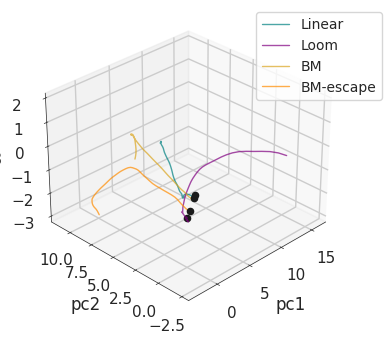

In [ ]:
subpanel = 'S6l'

rep_exp_ffile = ['jy-241204-f3,t2-stimR']
samples = [] # for csv saving

pre, stim_dur, post = [sec*resample_Hz for sec in [5, 6, 14]] # baseline/stim on/ITI
off = 3*resample_Hz # potential response window to offset of stimulus
trial_len = pre+stim_dur+post

for rep_exp in rep_exp_ffile:
  rep_exp, rep_ffile = rep_exp.split(',')
  for exp, ffile, plane_num, trial_num in zip(experiments[6:], fcn_files[6:], planeNum[6:], trialNum[6:]):
    if exp != rep_exp or ffile != rep_ffile: continue
    load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'
    print("fish #", exp, ': ', ffile)

    # load processed 2p
    data = np.load(load_path+'neuron_details.npz', allow_pickle=True)
    traces_Z = data['traces_Z']
    # load stim/trial
    with open(load_path+'stim_ON.pkl', 'rb') as f:
      stim_on = pickle.load(f)
    # load responsive cells
    data = np.load(output_path+'ttest_cells_long.npz',allow_pickle=True)
    cell_id, resp_arr = data['cell_id'], data['resp_arr']

    # get traces of response
    neuron_traces = [traces_Z[i] for i in cell_id]
    neuron_traces = np.array(neuron_traces); print('cell x timepoints', neuron_traces.shape)

    # run PCA
    n_PC = 25
    if len(neuron_traces) < n_PC: # neuron num > PC to show variance explained
      continue
    centered_traces =[t-np.mean(t) for t in neuron_traces] # pre process
    pca=PCA(n_components=n_PC)
    pca.fit(centered_traces)
    weights = pca.fit_transform(centered_traces)
    explained_variance_ratio = pca.explained_variance_ratio_
    # store reconstructed neural traces with
    tPCs=[]
    for i in range(n_PC):
      tmp = [m[i]*n for m,n in zip(weights, centered_traces)]
      tPCs.append(np.mean(tmp, axis=0))
    # get average trajectory for each stim type in PCA space
    stim_pca = [np.array([np.mean([t[i-resample_Hz:i+stim_dur] for i in stim if (i+stim_dur)<len(t) and (i>resample_Hz)], axis=0) for t in tPCs]) for stim in stim_on]

    # vis
    fig = plt.figure(figsize=(8,4))
    # plot trajectory of a few seconds in PCA space
    ax = fig.add_subplot(111, projection='3d')
    if rep_exp == 'jy-241204-f3' and rep_ffile=='t1-stimL': ax.view_init(elev=30, azim=-120)
    if rep_exp == 'jy-241204-f3' and rep_ffile=='t2-stimR': ax.view_init(elev=30, azim=-135)
    # visualize average neural traces projected in PC space
    for stim in range(len(stim_on)):
      ax.scatter(stim_pca[stim][0][0],stim_pca[stim][1][0],stim_pca[stim][2][0],color='k', s=20)
      ax.plot(stim_pca[stim][0][:],stim_pca[stim][1][:],stim_pca[stim][2][:],color=stim_colorz[stim],linewidth=1,alpha=0.7,label=stim_names[stim])
    ax.set_xlabel('pc1'); ax.set_ylabel('pc2'); ax.set_zlabel('pc3')
    plt.legend(bbox_to_anchor=(1.15,1),markerscale=0.7,borderaxespad=0.2,fontsize=10)
    print(figure_path+subpanel)
    plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
    plt.show()

    # save source data into csv
    series_dict = {}
    for i, stim in enumerate(stim_names):
      for j in range(n_PC)[:3]:
        col_name = f"{stim}_PC{j+1}"
        series_dict[col_name] = pd.Series(stim_pca[i][j])

    df = pd.DataFrame(series_dict)
    df.to_csv(csv_path+subpanel+'.csv', index=False)

# S6m - SVM time series (all stim)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S6m


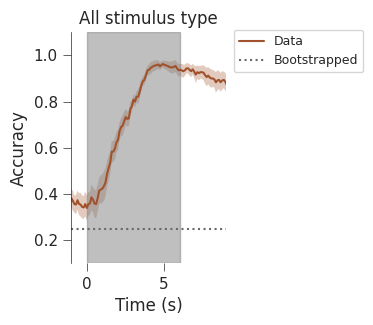

,data_0,data_1,data_2,data_3,data_4,data_5,data_6,data_7,data_8,data_9,...,bootstrapped_5,bootstrapped_6,bootstrapped_7,bootstrapped_8,bootstrapped_9,bootstrapped_10,bootstrapped_11,bootstrapped_12,bootstrapped_13,bootstrapped_14
0,0.28125,0.15625,0.34375,0.37500,0.34375,0.21875,0.25000,0.28125,0.25000,0.12500,...,0.21500,0.23750,0.25125,0.24625,0.24875,0.23500,0.26250,0.26750,0.25000,0.23000
1,0.34375,0.21875,0.34375,0.31250,0.31250,0.31250,0.18750,0.28125,0.21875,0.15625,...,0.26375,0.25875,0.25750,0.23750,0.25625,0.26125,0.25375,0.26250,0.23000,0.24000
2,0.25000,0.21875,0.31250,0.28125,0.46875,0.25000,0.21875,0.28125,0.15625,0.15625,...,0.23750,0.25375,0.26750,0.25625,0.28250,0.25000,0.25625,0.24750,0.25125,0.26000
3,0.31250,0.31250,0.31250,0.28125,0.40625,0.25000,0.21875,0.31250,0.12500,0.15625,...,0.25625,0.23750,0.26250,0.25875,0.24125,0.23625,0.23375,0.24875,0.27250,0.24875
4,0.28125,0.28125,0.34375,0.37500,0.31250,0.18750,0.31250,0.25000,0.18750,0.34375,...,0.25000,0.24000,0.23250,0.26625,0.23500,0.24125,0.25375,0.24750,0.22750,0.26500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,0.43750,0.28125,0.46875,0.53125,0.56250,0.43750,0.28125,0.31250,0.31250,0.28125,...,0.26750,0.23500,0.25500,0.25500,0.26750,0.26625,0.23250,0.24625,0.25875,0.24875
246,0.34375,0.34375,0.37500,0.62500,0.59375,0.43750,0.31250,0.34375,0.31250,0.43750,...,0.26875,0.24250,0.24750,0.26125,0.25500,0.26875,0.24125,0.27750,0.26000,0.24625
247,0.46875,0.21875,0.34375,0.56250,0.62500,0.40625,0.34375,0.34375,0.34375,0.43750,...,0.25625,0.22750,0.25625,0.23375,0.24500,0.26500,0.23750,0.24375,0.26625,0.26750
248,0.34375,0.34375,0.28125,0.56250,0.75000,0.53125,0.37500,0.34375,0.34375,0.37500,...,0.26875,0.22500,0.25125,0.23125,0.26000,0.24250,0.23500,0.25375,0.26250,0.27500


In [ ]:
subpanel = 'S6m'
decoder = 'svm_all_stim'; decoder_name = 'All stimulus type'

Real, Bootstrapped = [], []
for exp, ffile, plane_num, trial_num in zip(experiments[:], fcn_files[:], planeNum[:], trialNum[:]):
  [t1, t2, t3, t4] = [int(t) for t in trial_num.split(' ')]
  load_path = data_path + exp + '/' + ffile + '/';
  output_path = save_path + exp + '/' + ffile + '/'
  if np.sum([t>=8 for t in [t1,t2,t3,t4]])!=4: continue
  with open(output_path+'Decoders/'+decoder+'.pkl','rb') as f: data = pickle.load(f)

  # n_neurons, n_components, n_trials = data['n_neurons'], data['n_components'], data['n_trials']
  real_inst, perm_inst = data['real_inst'], data['perm_inst']

  Real.append(real_inst)
  Bootstrapped.append(perm_inst)

# make time to
rel_time = np.linspace(-5,20,25*resample_Hz); rel_sec = np.round(rel_time,2)

# Visualization
plt.figure(figsize=[2,3])
mean1, sem1 = np.mean(Real, axis=0), stats.sem(Real, axis=0)
mean2, sem2 = np.mean(Bootstrapped, axis=0), stats.sem(Bootstrapped, axis=0)

plt.plot(rel_sec, mean1, 'sienna', label='Data')
plt.fill_between(rel_sec, mean1+sem1, mean1-sem1, alpha=0.3, color='sienna',lw=0)
plt.axhline(np.nanmean(mean2), color='dimgrey',ls=':', label='Bootstrapped')
plt.axvspan(0,6, color='gray',alpha=0.5);
plt.xlim(-1,9); plt.xlabel('Time (s)')
plt.legend(fontsize=9, bbox_to_anchor=(1.01, 0.8)); sns.despine(bottom=True)
plt.ylabel('Accuracy'); plt.title(decoder_name); plt.ylim(0.1,1.1)
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
for i, d in enumerate(Real): series_dict['data_'+str(i)] = pd.Series(d)
for i, d in enumerate(Bootstrapped): series_dict['bootstrapped_'+str(i)] = pd.Series(np.mean(d,axis=0))
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+f".csv", index=False)

# S6n - SVM time series (BM vs linear)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S6n


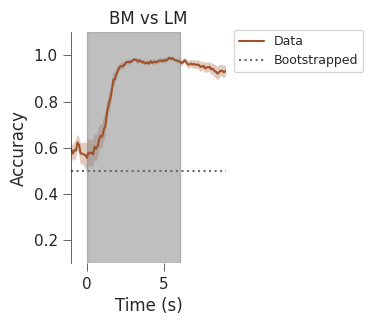

,data_0,data_1,data_2,data_3,data_4,data_5,data_6,data_7,data_8,data_9,...,bootstrapped_5,bootstrapped_6,bootstrapped_7,bootstrapped_8,bootstrapped_9,bootstrapped_10,bootstrapped_11,bootstrapped_12,bootstrapped_13,bootstrapped_14
0,0.37500,0.56250,0.37500,0.43750,0.59375,0.37500,0.40625,0.68750,0.56250,0.50000,...,0.51500,0.50875,0.48750,0.49625,0.50250,0.52125,0.49000,0.51125,0.50375,0.48875
1,0.37500,0.56250,0.40625,0.43750,0.56250,0.40625,0.37500,0.65625,0.53125,0.43750,...,0.50000,0.52875,0.51125,0.52625,0.51500,0.51250,0.52250,0.47000,0.52500,0.52500
2,0.37500,0.62500,0.46875,0.46875,0.59375,0.50000,0.37500,0.65625,0.56250,0.37500,...,0.49250,0.49375,0.50000,0.52500,0.49875,0.50625,0.50125,0.51625,0.50750,0.50000
3,0.43750,0.65625,0.46875,0.40625,0.62500,0.50000,0.50000,0.68750,0.53125,0.53125,...,0.50500,0.51000,0.49875,0.51375,0.47875,0.51000,0.48375,0.51250,0.50625,0.50250
4,0.46875,0.65625,0.46875,0.53125,0.56250,0.53125,0.59375,0.71875,0.53125,0.53125,...,0.49375,0.53000,0.49875,0.45250,0.51000,0.49875,0.50125,0.48375,0.49625,0.48000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,0.71875,0.78125,0.59375,0.84375,0.84375,0.65625,0.56250,0.68750,0.59375,0.53125,...,0.48000,0.51250,0.52125,0.48250,0.50125,0.51250,0.51000,0.53000,0.52125,0.50875
246,0.65625,0.68750,0.59375,0.93750,0.78125,0.68750,0.46875,0.75000,0.50000,0.50000,...,0.48375,0.49625,0.49750,0.49750,0.50125,0.49750,0.46875,0.47000,0.50500,0.49625
247,0.71875,0.75000,0.68750,0.93750,0.84375,0.68750,0.53125,0.68750,0.53125,0.50000,...,0.50875,0.49500,0.51625,0.48125,0.46125,0.51625,0.47375,0.52125,0.50375,0.51375
248,0.68750,0.68750,0.53125,0.87500,0.87500,0.65625,0.65625,0.71875,0.56250,0.62500,...,0.52625,0.47875,0.51375,0.50125,0.50875,0.49375,0.47000,0.50500,0.47750,0.51125


In [ ]:
subpanel = 'S6n'
decoder = 'svm_social_nonsocial'; decoder_name = 'BM vs LM'

Real, Bootstrapped = [], []
for exp, ffile, plane_num, trial_num in zip(experiments[:], fcn_files[:], planeNum[:], trialNum[:]):
  [t1, t2, t3, t4] = [int(t) for t in trial_num.split(' ')]
  load_path = data_path + exp + '/' + ffile + '/';
  output_path = save_path + exp + '/' + ffile + '/'
  if np.sum([t>=8 for t in [t1,t2,t3,t4]])!=4: continue
  with open(output_path+'Decoders/'+decoder+'.pkl','rb') as f: data = pickle.load(f)

  # n_neurons, n_components, n_trials = data['n_neurons'], data['n_components'], data['n_trials']
  real_inst, perm_inst = data['real_inst'], data['perm_inst']

  Real.append(real_inst)
  Bootstrapped.append(perm_inst)

# make time to
rel_time = np.linspace(-5,20,25*resample_Hz); rel_sec = np.round(rel_time,2)

# Visualization
plt.figure(figsize=[2,3])
mean1, sem1 = np.mean(Real, axis=0), stats.sem(Real, axis=0)
mean2, sem2 = np.mean(Bootstrapped, axis=0), stats.sem(Bootstrapped, axis=0)

plt.plot(rel_sec, mean1, 'sienna', label='Data')
plt.fill_between(rel_sec, mean1+sem1, mean1-sem1, alpha=0.3, color='sienna',lw=0)
plt.axhline(np.nanmean(mean2), color='dimgrey',ls=':', label='Bootstrapped')
plt.axvspan(0,6, color='gray',alpha=0.5);
plt.xlim(-1,9); plt.xlabel('Time (s)')
plt.legend(fontsize=9, bbox_to_anchor=(1.01, 0.8)); sns.despine(bottom=True)
plt.ylabel('Accuracy'); plt.title(decoder_name); plt.ylim(0.1,1.1)
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
for i, d in enumerate(Real): series_dict['data_'+str(i)] = pd.Series(d)
for i, d in enumerate(Bootstrapped): series_dict['bootstrapped_'+str(i)] = pd.Series(np.mean(d,axis=0))
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+f".csv", index=False)

# S6o - SVM time series (neutral vs dangerous)

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S6o


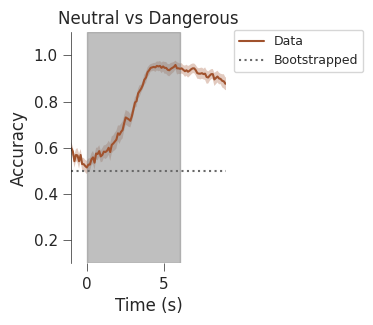

,data_0,data_1,data_2,data_3,data_4,data_5,data_6,data_7,data_8,data_9,...,bootstrapped_5,bootstrapped_6,bootstrapped_7,bootstrapped_8,bootstrapped_9,bootstrapped_10,bootstrapped_11,bootstrapped_12,bootstrapped_13,bootstrapped_14
0,0.56250,0.40625,0.56250,0.53125,0.59375,0.46875,0.56250,0.56250,0.59375,0.50000,...,0.51750,0.48875,0.49750,0.48375,0.49500,0.50500,0.50875,0.50000,0.48625,0.50875
1,0.65625,0.43750,0.56250,0.53125,0.43750,0.43750,0.59375,0.56250,0.50000,0.43750,...,0.47625,0.52125,0.50000,0.49375,0.53125,0.50750,0.49500,0.48125,0.49250,0.51125
2,0.68750,0.46875,0.62500,0.53125,0.46875,0.53125,0.53125,0.59375,0.59375,0.53125,...,0.51375,0.51375,0.51750,0.47375,0.49375,0.48000,0.50250,0.48375,0.51250,0.50625
3,0.62500,0.43750,0.68750,0.50000,0.46875,0.56250,0.56250,0.53125,0.62500,0.53125,...,0.51125,0.49500,0.48250,0.51375,0.49500,0.52250,0.48750,0.49500,0.53500,0.49375
4,0.65625,0.46875,0.50000,0.46875,0.50000,0.65625,0.62500,0.56250,0.65625,0.53125,...,0.48375,0.51250,0.47875,0.50875,0.50250,0.51250,0.49250,0.51375,0.50625,0.50750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,0.53125,0.46875,0.59375,0.71875,0.78125,0.65625,0.78125,0.71875,0.68750,0.59375,...,0.48375,0.49375,0.50375,0.52250,0.52375,0.48125,0.50250,0.51875,0.53500,0.49500
246,0.59375,0.34375,0.59375,0.71875,0.65625,0.71875,0.68750,0.68750,0.68750,0.75000,...,0.50250,0.51000,0.49000,0.49250,0.51000,0.50625,0.50750,0.49125,0.48875,0.49250
247,0.56250,0.53125,0.53125,0.65625,0.65625,0.68750,0.59375,0.68750,0.62500,0.59375,...,0.47875,0.47875,0.49875,0.49125,0.46375,0.50875,0.50250,0.50375,0.53500,0.50375
248,0.56250,0.62500,0.56250,0.62500,0.53125,0.68750,0.65625,0.65625,0.59375,0.56250,...,0.50250,0.49625,0.50625,0.49000,0.51500,0.49875,0.49000,0.51750,0.48125,0.51000


In [ ]:
subpanel = 'S6o'
decoder = 'svm_neutral_danger'; decoder_name = 'Neutral vs Dangerous'

Real, Bootstrapped = [], []
for exp, ffile, plane_num, trial_num in zip(experiments[:], fcn_files[:], planeNum[:], trialNum[:]):
  [t1, t2, t3, t4] = [int(t) for t in trial_num.split(' ')]
  load_path = data_path + exp + '/' + ffile + '/';
  output_path = save_path + exp + '/' + ffile + '/'
  if np.sum([t>=8 for t in [t1,t2,t3,t4]])!=4: continue
  with open(output_path+'Decoders/'+decoder+'.pkl','rb') as f: data = pickle.load(f)

  # n_neurons, n_components, n_trials = data['n_neurons'], data['n_components'], data['n_trials']
  real_inst, perm_inst = data['real_inst'], data['perm_inst']

  Real.append(real_inst)
  Bootstrapped.append(perm_inst)

# make time to
rel_time = np.linspace(-5,20,25*resample_Hz); rel_sec = np.round(rel_time,2)

# Visualization
plt.figure(figsize=[2,3])
mean1, sem1 = np.mean(Real, axis=0), stats.sem(Real, axis=0)
mean2, sem2 = np.mean(Bootstrapped, axis=0), stats.sem(Bootstrapped, axis=0)

plt.plot(rel_sec, mean1, 'sienna', label='Data')
plt.fill_between(rel_sec, mean1+sem1, mean1-sem1, alpha=0.3, color='sienna',lw=0)
plt.axhline(np.nanmean(mean2), color='dimgrey',ls=':', label='Bootstrapped')
plt.axvspan(0,6, color='gray',alpha=0.5);
plt.xlim(-1,9); plt.xlabel('Time (s)')
plt.legend(fontsize=9, bbox_to_anchor=(1.01, 0.8)); sns.despine(bottom=True)
plt.ylabel('Accuracy'); plt.title(decoder_name); plt.ylim(0.1,1.1)
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
for i, d in enumerate(Real): series_dict['data_'+str(i)] = pd.Series(d)
for i, d in enumerate(Bootstrapped): series_dict['bootstrapped_'+str(i)] = pd.Series(np.mean(d,axis=0))
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+f".csv", index=False)

# S6p - SVM time series BM vs BM-escape

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S6p


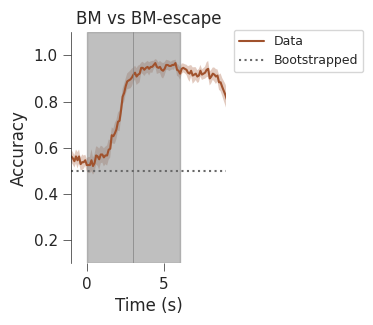

,data_0,data_1,data_2,data_3,data_4,data_5,data_6,data_7,data_8,data_9,...,bootstrapped_5,bootstrapped_6,bootstrapped_7,bootstrapped_8,bootstrapped_9,bootstrapped_10,bootstrapped_11,bootstrapped_12,bootstrapped_13,bootstrapped_14
0,0.3750,0.4375,0.6875,0.4375,0.5000,0.4375,0.5625,0.5000,0.3125,0.6250,...,0.5250,0.5050,0.5100,0.4925,0.4825,0.5150,0.5075,0.4900,0.5125,0.5025
1,0.5000,0.5000,0.6875,0.3750,0.4375,0.4375,0.6875,0.5625,0.3125,0.6250,...,0.4850,0.4975,0.4625,0.5175,0.5400,0.5150,0.5075,0.5125,0.4875,0.5100
2,0.5625,0.3750,0.6250,0.3125,0.6250,0.3750,0.5625,0.6250,0.3125,0.5625,...,0.5225,0.4900,0.5100,0.5025,0.5150,0.5000,0.5350,0.4675,0.4875,0.5000
3,0.5000,0.4375,0.5625,0.5000,0.5000,0.4375,0.5000,0.6250,0.2500,0.5000,...,0.4950,0.5175,0.5125,0.5200,0.4975,0.4900,0.5300,0.4600,0.5400,0.5150
4,0.5625,0.1875,0.5000,0.3125,0.5000,0.4375,0.5000,0.4375,0.3750,0.3750,...,0.4800,0.5075,0.5325,0.5200,0.5000,0.4875,0.4750,0.4950,0.5000,0.5275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,0.5000,0.5000,0.4375,0.4375,0.3750,0.3750,0.4375,0.3750,0.4375,0.5000,...,0.4750,0.5125,0.4850,0.5150,0.5075,0.5075,0.5425,0.4925,0.4750,0.4900
246,0.6250,0.3750,0.5625,0.5000,0.4375,0.3750,0.5000,0.5000,0.6250,0.6250,...,0.4700,0.4600,0.5125,0.5400,0.5075,0.4900,0.4900,0.5225,0.4900,0.5225
247,0.4375,0.3125,0.5000,0.4375,0.5000,0.3125,0.4375,0.5625,0.6250,0.6250,...,0.4675,0.5125,0.5150,0.5150,0.5125,0.5025,0.5100,0.5250,0.4900,0.5050
248,0.4375,0.4375,0.4375,0.5625,0.6875,0.1875,0.3125,0.5625,0.6250,0.5625,...,0.4950,0.4925,0.5150,0.4725,0.5125,0.5350,0.4925,0.5050,0.5250,0.5000


In [ ]:
subpanel = 'S6p'
decoder = 'svm_swim_escp'; decoder_name = 'BM vs BM-escape'

Real, Bootstrapped = [], []
for exp, ffile, plane_num, trial_num in zip(experiments[:], fcn_files[:], planeNum[:], trialNum[:]):
  [t1, t2, t3, t4] = [int(t) for t in trial_num.split(' ')]
  load_path = data_path + exp + '/' + ffile + '/';
  output_path = save_path + exp + '/' + ffile + '/'
  if np.sum([t>=8 for t in [t1,t2,t3,t4]])!=4: continue
  with open(output_path+'Decoders/'+decoder+'.pkl','rb') as f: data = pickle.load(f)

  # n_neurons, n_components, n_trials = data['n_neurons'], data['n_components'], data['n_trials']
  real_inst, perm_inst = data['real_inst'], data['perm_inst']

  Real.append(real_inst)
  Bootstrapped.append(perm_inst)

# make time to
rel_time = np.linspace(-5,20,25*resample_Hz); rel_sec = np.round(rel_time,2)

# Visualization
plt.figure(figsize=[2,3])
mean1, sem1 = np.mean(Real, axis=0), stats.sem(Real, axis=0)
mean2, sem2 = np.mean(Bootstrapped, axis=0), stats.sem(Bootstrapped, axis=0)

plt.plot(rel_sec, mean1, 'sienna', label='Data')
plt.fill_between(rel_sec, mean1+sem1, mean1-sem1, alpha=0.3, color='sienna',lw=0)
plt.axvline(3,color='gray',lw=0.5)
plt.axhline(np.nanmean(mean2), color='dimgrey',ls=':', label='Bootstrapped')
plt.axvspan(0,6, color='gray',alpha=0.5);
plt.xlim(-1,9); plt.xlabel('Time (s)')
plt.legend(fontsize=9, bbox_to_anchor=(1.01, 0.8)); sns.despine(bottom=True)
plt.ylabel('Accuracy'); plt.title(decoder_name); plt.ylim(0.1,1.1)
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+f".pdf",bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
for i, d in enumerate(Real): series_dict['data_'+str(i)] = pd.Series(d)
for i, d in enumerate(Bootstrapped): series_dict['bootstrapped_'+str(i)] = pd.Series(np.mean(d,axis=0))
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+f".csv", index=False)

# S6q - SVM stim ON stats

/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S6q


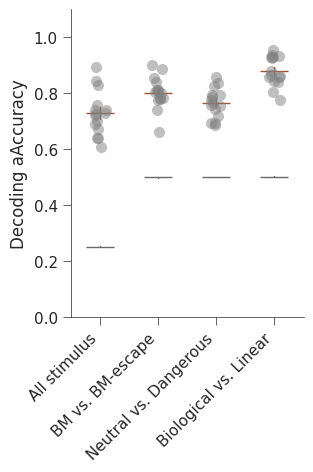


All stimulus: data_vs_shuffle:
N = 15, 15
data: mean, sem = 0.729, 0.020
bootstrapped: mean, sem = 0.252, 0.001

Normality test (Shapiro-Wilk):
Group data: W = 0.948, p = 0.494
Group bootstrapped: W = 0.974, p = 0.914
all groups are normally distributed → use parametric test.

T-test between data and bootstrapped: t = 23.449, p = 6.0124449477e-20

BM vs. BM-escape: data_vs_shuffle:
N = 15, 15
data: mean, sem = 0.802, 0.015
bootstrapped: mean, sem = 0.500, 0.001

Normality test (Shapiro-Wilk):
Group data: W = 0.936, p = 0.339
Group bootstrapped: W = 0.931, p = 0.285
all groups are normally distributed → use parametric test.

T-test between data and bootstrapped: t = 20.384, p = 2.4617118939e-18

Neutral vs. Dangerous: data_vs_shuffle:
N = 15, 15
data: mean, sem = 0.766, 0.014
bootstrapped: mean, sem = 0.500, 0.001

Normality test (Shapiro-Wilk):
Group data: W = 0.964, p = 0.755
Group bootstrapped: W = 0.981, p = 0.975
all groups are normally distributed → use parametric test.

T-test b

In [ ]:
subpanel = 'S6q'

decoders = ['svm_all_stim', 'svm_swim_escp', 'svm_neutral_danger', 'svm_social_nonsocial']
d_names = ['All stimulus', 'BM vs. BM-escape', 'Neutral vs. Dangerous', 'Biological vs. Linear']

Real = {key: [] for key in d_names}; Bootstrapped = {key: [] for key in d_names}

for exp, ffile, plane_num, trial_num in zip(experiments[:], fcn_files[:], planeNum[:], trialNum[:]):
  [t1, t2, t3, t4] = [int(t) for t in trial_num.split(' ')]
  load_path = data_path + exp + '/' + ffile + '/';
  output_path = save_path + exp + '/' + ffile + '/'
  if np.sum([t>=8 for t in [t1,t2,t3,t4]])!=4: continue

  for decoder_name, decoder in zip(d_names, decoders):
    with open(output_path+'Decoders/'+decoder+'.pkl','rb') as f: data = pickle.load(f)

    # n_neurons, n_components, n_trials = data['n_neurons'], data['n_components'], data['n_trials']
    real_inst, perm_inst = data['real_inst'], data['perm_inst']

    # get the mean of accuracy score during stimulus ON
    start, end = [sec*resample_Hz for sec in [5, 11]]

    Real[decoder_name].append(np.mean(real_inst[start:end]))
    Bootstrapped[decoder_name].append(np.mean(perm_inst[:, start:end]))

# STATS
group_values = d_names
summary_data = Real
summary_data2 = Bootstrapped

# print('Each point is all training from a fish')
plt.figure(figsize=[3,4])
sns.stripplot(data=summary_data,color='gray',alpha=0.5,size=8,label='data')
sns.pointplot(data=summary_data,color='sienna',linestyle="none",marker="_",errorbar='se',markersize=20,markeredgewidth=1,errwidth=1)

sns.pointplot(data=summary_data2,color='dimgrey',linestyle="none",marker="_",errorbar='se',markersize=20,markeredgewidth=1,errwidth=1,label='bootstrapped')

plt.ylabel('Decoding aAccuracy'); plt.ylim(0,1.1);
plt.xticks(np.arange(len(d_names)),d_names,rotation=45,ha='right');
sns.despine();
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
for key, values in summary_data.items():
  col_name = f"{key}_data"
  series_dict[col_name] = pd.Series(values)
for key, values in summary_data2.items():
  col_name = f"{key}_bootstrapped"
  series_dict[col_name] = pd.Series(values)
df = pd.DataFrame(series_dict)
df.to_csv(csv_path+subpanel+".csv", index=False)

for decoder_name in d_names:
  print(f"\n{decoder_name}: data_vs_shuffle:")
  print(f"N = {len(summary_data[decoder_name])}, {len(summary_data2[decoder_name])}")
  print(f"data: mean, sem = {np.mean(summary_data[decoder_name]):.3f}, {stats.sem(summary_data[decoder_name]):.3f}")
  print(f"bootstrapped: mean, sem = {np.mean(summary_data2[decoder_name]):.3f}, {stats.sem(summary_data2[decoder_name]):.3f}")

  compare = ['data', 'bootstrapped'];
  summary = [summary_data[decoder_name], summary_data2[decoder_name]]

  # -- 1. Test for normality in each group -- ##
  print("\nNormality test (Shapiro-Wilk):")
  normality_results = {}
  for group, data in zip(compare, summary):
    stat, p = stats.shapiro(data)
    normality_results[group] = {'W': stat, 'p': p}
  for g, res in normality_results.items():
    print(f"Group {g}: W = {res['W']:.3f}, p = {res['p']:.3f}")

  is_normal = all(res['p'] > 0.05 for res in normality_results.values());
  if is_normal: print("all groups are normally distributed \u2192 use parametric test.")
  else: print("not all groups are normally distributed \u2192 use nonparametric test.")

  ## -- 2. Group comparisons (& post hoc test) -- ##
  unique_groups = 2; annotation_dict = {}
  #  Two groups: t-test or Mann-Whitney
  if is_normal:
    stat, p = stats.ttest_ind(summary[0], summary[1])
    print(f"\nT-test between {compare[0]} and {compare[1]}: t = {stat:.3f}, p = {p:.10e}")
  else:
    stat, p = stats.mannwhitneyu(summary[0], summary[1])
    print(f"\nMann-Whitney U between {compare[0]} and {compare[1]}: U = {stat:.3f}, p = {p:.10e}")

# S6r-s

In [ ]:
# average tail movement for all stim types # show Z score and binary both
# separate trials with movement or not # mean during 0-6s over certain Z score

In [ ]:
pre, stim_dur, post = [sec*resample_Hz for sec in [5, 6, 14]] # baseline/stim on/ITI
off = 3*resample_Hz # potential response window to offset of stimulus
Z_threshold = 2

# across fish summary
Z_per_stim = {n: [] for n in stim_names}
MOTION_per_stim = {n: [] for n in stim_names}

for exp, ffile, plane_num, trial_num in zip(experiments[::], fcn_files[::], planeNum[::], trialNum[::]):
  [t1, t2, t3, t4] = [int(t) for t in trial_num.split(' ')]
  load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'
  # print("fish #", exp, ': ', ffile)
  # load cell PSTHs
  with open(output_path+'PSTHs.pkl', 'rb') as f:
    PSTHs = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]
  # load tail PSTHs
  with open(output_path+'tail_move_psths.pkl', 'rb') as f:
    tail_Z_PSTHs = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]

  # collect
  Z_fish = {n: [] for n in stim_names}; motion_fish = {n: [] for n in stim_names}
  for i, stim in enumerate(stim_names):
    for t in tail_Z_PSTHs[i]:
      Z_fish[stim].append(t)
      m = t > Z_threshold; motion_fish[stim].append(m)

  # append to across fish summary
  for n in stim_names:
    Z_per_stim[n].append(np.mean(Z_fish[n],axis=0))
    MOTION_per_stim[n].append(np.mean(motion_fish[n],axis=0))

## S6r - tail motion during stim

Binned
/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S6r


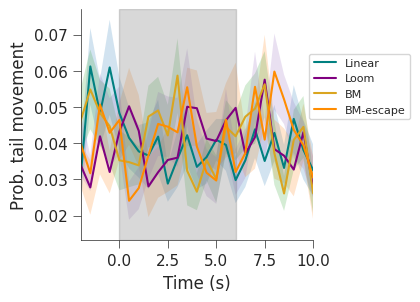

,Linear,Loom,BM,BM-escape
0,0.048635,0.035534,0.037175,0.032878
1,0.036063,0.038209,0.042016,0.035833
2,0.031804,0.043804,0.031810,0.043812
3,0.042299,0.036132,0.026712,0.051212
4,0.028005,0.038484,0.029511,0.036283
5,0.031783,0.030452,0.021563,0.031442
6,0.030542,0.033987,0.046198,0.039852
7,0.061201,0.027772,0.054839,0.031685
8,0.048246,0.041902,0.048397,0.050638
9,0.060939,0.032034,0.044661,0.042870


In [ ]:
subpanel = 'S6r'

# --- parameters ---
bin_length = 0.5 # seconds
bin_size = int(bin_length * resample_Hz)

# --- helpers ---
def bin_time_series(arr, bin_size):
    n_fish, T = arr.shape
    n_bins = T // bin_size
    arr = arr[:, :n_bins * bin_size]
    return arr.reshape(n_fish, n_bins, bin_size).mean(axis=2)
def mean_sem(arr):
    return arr.mean(axis=0), arr.std(axis=0) / np.sqrt(arr.shape[0])

# --- convert to arrays ---
Z_arr = {stim: np.array(Z_per_stim[stim]) for stim in stim_names}
M_arr = {stim: np.array(MOTION_per_stim[stim]) for stim in stim_names}

# --- bin data ---
Z_binned = {stim: bin_time_series(Z_arr[stim], bin_size) for stim in stim_names}
M_binned = {stim: bin_time_series(M_arr[stim], bin_size) for stim in stim_names}

# --- time axis ---
T = Z_arr[stim_names[0]].shape[1]
time = (np.arange(T) - pre) / resample_Hz
time_binned = time[:Z_binned[stim_names[0]].shape[1] * bin_size:bin_size]

print('Binned')
# --- plotting ---
plt.figure(figsize=[3,3])

for i, stim in enumerate(stim_names):
  mean_m, sem_m = mean_sem(M_binned[stim])
  plt.plot(time_binned, mean_m, label=stim, color=stim_colorz[i])
  plt.fill_between(time_binned, mean_m - sem_m, mean_m + sem_m, alpha=0.2,lw=0)

plt.xlim(-2,10)
plt.axvspan(0, stim_dur / resample_Hz, color='gray', alpha=0.3)
plt.axvline(10/0.5,color='gray',lw=0.5)
plt.xlabel('Time (s)'); plt.ylabel('Prob. tail movement')
sns.despine()
plt.legend(bbox_to_anchor=[1.2, 0.5], fontsize=8)
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+".pdf",bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}
for i, stim in enumerate(stim_names):
  mean_m, sem_m = mean_sem(M_binned[stim])
  series_dict[stim] = pd.Series(mean_m)
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)

## S6s - motion modulation of response

In [ ]:
pre, stim_dur, post = [sec*resample_Hz for sec in [5, 6, 14]] # baseline/stim on/ITI
off = 3*resample_Hz # potential response window to offset of stimulus
Z_threshold = 2

# across fish summary
MOTION_per_stim = {n: [] for n in stim_names} # mean across trials
across_fish_summary = {f'{n}_move':[] for n in stim_names}
across_fish_summary.update({f'{n}_no_move':[] for n in stim_names})
trial_counts = {'move': 0, 'no_move': 0}

for exp, ffile, plane_num, trial_num in zip(experiments[::], fcn_files[::], planeNum[::], trialNum[::]):
  [t1, t2, t3, t4] = [int(t) for t in trial_num.split(' ')]
  load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'
  # print("fish #", exp, ': ', ffile)
  # load responsive cells
  data = np.load(output_path+'ttest_cells_long.npz', allow_pickle=True)
  cell_id, resp_arr = data['cell_id'], data['resp_arr']
  # load cell PSTHs
  with open(output_path+'PSTHs.pkl', 'rb') as f:
    PSTHs = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]
  # load tail PSTHs
  with open(output_path+'tail_move_psths.pkl', 'rb') as f:
    tail_Z_PSTHs = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]

  # collect tail movements
  motion_fish = {n: [] for n in stim_names} # stim x trial
  for i, stim in enumerate(stim_names):
    # tail movement
    for t in tail_Z_PSTHs[i]: m = t > Z_threshold; motion_fish[stim].append(m)

  # categorize single psth into whether there's movement
  big_list = {f'{n}_move': [] for n in stim_names}
  big_list.update({f'{n}_no_move': [] for n in stim_names})

  start, end = pre, pre+stim_dur #+2*resample_Hz
  trial_cnt = {'move': 0, 'no_move': 0}
  for i, stim in enumerate(stim_names):
    for j, trial in enumerate(motion_fish[stim]):
      tmp = np.mean(trial[start:end])
      # motion_tmp[stim].append(tmp)
      if tmp>0:
        tr = np.array([PSTHs[cell][i][j] for cell in cell_id])
        big_list[f'{stim}_move'].append(np.mean(tr,axis=0))
        trial_cnt['move'] += 1
      else:
        tr = np.array([PSTHs[cell][i][j] for cell in cell_id])
        big_list[f'{stim}_no_move'].append(np.mean(tr,axis=0))
        trial_cnt['no_move'] += 1
    # break

  # append to across fish summary
  for n in stim_names:
    if len(big_list[f'{n}_move']) >0:
      across_fish_summary[f'{n}_move'].append(np.mean(big_list[f'{n}_move'],axis=0))
    if len(big_list[f'{n}_no_move']) > 0:
      across_fish_summary[f'{n}_no_move'].append(np.mean(big_list[f'{n}_no_move'],axis=0))
    trial_counts['move'] += trial_cnt['move']; trial_counts['no_move'] += trial_cnt['no_move']

print(trial_counts)

{'move': 2704, 'no_move': 832}


/content/drive/MyDrive/Personal_notebooks/Johsien_Notebook/Yu_escape_paper/Manuscript/Figures/figures_v7/subpanels/S6s


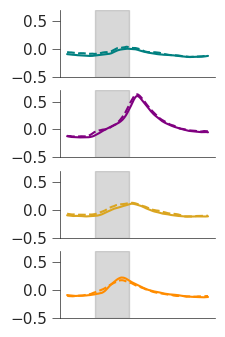

,Linear_move,Linear_no_move,Loom_move,Loom_no_move,BM_move,BM_no_move,BM-escape_move,BM-escape_no_move
0,-0.090908,-0.054569,-0.121803,-0.113987,-0.099509,-0.069408,-0.088956,-0.099020
1,-0.092151,-0.056784,-0.123733,-0.116691,-0.100677,-0.073428,-0.090888,-0.102006
2,-0.093300,-0.057552,-0.125300,-0.118990,-0.102269,-0.075355,-0.092063,-0.105121
3,-0.094486,-0.059117,-0.127701,-0.119829,-0.104306,-0.076869,-0.093017,-0.107258
4,-0.096109,-0.060933,-0.130377,-0.119895,-0.105860,-0.078361,-0.094150,-0.107879
...,...,...,...,...,...,...,...,...
245,-0.128900,-0.124744,-0.046670,-0.032086,-0.120702,-0.109831,-0.126781,-0.107415
246,-0.127188,-0.124152,-0.047376,-0.031950,-0.120135,-0.109113,-0.125677,-0.106894
247,-0.125523,-0.123175,-0.049350,-0.032152,-0.119982,-0.108878,-0.124537,-0.107009
248,-0.123861,-0.122299,-0.050502,-0.033081,-0.119309,-0.107184,-0.123923,-0.106475


In [ ]:
subpanel = 'S6s'
# VISUALIZAE
plt.figure(figsize=[2,4])
# plt.subplot(121)
for i, stim in enumerate(stim_names):
  plt.subplot(4,1,i+1)
  m = np.mean(across_fish_summary[f'{stim}_move'],axis=0)
  plt.plot(m, color=stim_colorz[i], label=f'{stim}_move')
  nm = np.mean(across_fish_summary[f'{stim}_no_move'],axis=0)
  plt.plot(nm, color=stim_colorz[i], ls='--',label=f'{stim} w/o motion')
  plt.xticks([]); plt.ylim(-0.5,0.7)
  sns.despine(); plt.axvspan(pre, pre+stim_dur, color='gray', alpha=0.3)
print(figure_path+subpanel)
plt.savefig(figure_path+subpanel+'.pdf',bbox_inches='tight')
plt.show()

# save source data into csv
series_dict = {}

for i, stim in enumerate(stim_names):
  m = np.mean(across_fish_summary[f'{stim}_move'],axis=0)
  nm = np.mean(across_fish_summary[f'{stim}_no_move'],axis=0)
  series_dict[f'{stim}_move'] = pd.Series(m)
  series_dict[f'{stim}_no_move'] = pd.Series(nm)
df = pd.DataFrame(series_dict)
display(df)
df.to_csv(csv_path+subpanel+'.csv', index=False)